# LV 3D Reconstruction — Signed-Distance INR (Watertight by Construction)

## Phase-Conditioned SDF Network with Monotone-Epi Coupling

This notebook implements the plan in
[`docs/plan-sdf-watertight-by-construction.md`](docs/plan-sdf-watertight-by-construction.md).
It is a **drop-in replacement** for `training-model-v2.ipynb`: the
encoder, Fourier positional encoding, dataloader / collate, optimiser,
multi-GPU harness and patient split logic are reused unchanged. Only the
**decoder heads**, the **loss**, the **per-sample targets** (SDF instead
of occupancy) and the **mesh-extraction call** differ.

### Why an SDF?

| Property | Occupancy (v2) | **SDF (this run)** |
|---|---|---|
| Surface | $\{x:\sigma(f)=0.5\}$ | $\{x:f(x)=0\}$ |
| Closed mesh? | not guaranteed → relies on `repair_watertight` + `synthesize_caps` + PyMeshFix | **yes** — by Sard's theorem, the zero level-set of a continuous $f$ on a regular value is a closed 2-manifold inside the bbox |
| Wall thickness | ray cast (fragile at apex; `p5 = 0 mm` on patient001) | **analytic**: $\delta(x) = f_\text{endo}(x) - f_\text{epi}(x)$ |
| Off-surface signal | flat sigmoid → vanishing gradient | actual signed distance → strong gradient everywhere |
| Normals | finite differences on the mesh | analytic: $\nabla f / \lVert\nabla f\rVert$ |

### Two key architectural ideas

1. **Monotone-epi parameterisation.** Predict $f_\text{endo}$ directly
   and $f_\text{epi} = f_\text{endo} - \delta$ with
   $\delta = \operatorname{softplus}(\cdot) > 0$. Makes "wall thickness
   positive everywhere" a structural property of the model — not
   something the loss has to enforce after the fact. Directly addresses
   the patient001 collapse mode in v2.
2. **Geometric (sphere) initialisation.** Initialise the network so
   that at $t=0$ it represents the SDF of a sphere of radius
   $r_0 \approx 0.5$. Sidesteps the cold-start collapse to
   $f \equiv 0$ that plagues randomly-initialised SDF networks.

### Six-term loss

$$
\mathcal{L} = \lambda_\text{surf}\mathcal{L}_\text{surf}
            + \lambda_\text{eik}\mathcal{L}_\text{eik}
            + \lambda_\text{off}\mathcal{L}_\text{off}
            + \lambda_\text{normal}\mathcal{L}_\text{normal}
            + \lambda_\text{WT}\mathcal{L}_\text{WT}
            + \lambda_\text{L1}\mathcal{L}_\text{L1}
$$

— the standard DeepSDF / IGR / SAL family, plus an L1 supervision term
on the cached query points (reuses the existing per-sample point
distribution from `build-lv-cache.ipynb`). Gradients $\nabla_x f$ are
computed via `torch.autograd.grad` under an explicit
`autocast(enabled=False)` override (the AMP path is unstable for
second-order use in PyTorch 2.x).

## 1. Setup

In [1]:
%pip install -q vtk scikit-image tqdm scipy nibabel scikit-learn trimesh rtree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 12.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, time, math, hashlib, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import KDTree
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
import trimesh
import trimesh.smoothing

warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42); random.seed(42)

N_GPUS = torch.cuda.device_count()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}")
for i in range(N_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name}  ({p.total_memory/1e9:.1f} GB)")

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

Device: cuda  |  GPUs: 2
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)


In [3]:
# Training mode: "ed_only" | "es_only" | "combined"
MODE = "combined"

CFG = dict(
    mode           = MODE,

    # ── Cache paths ──────────────────────────────────────────
    ed_cache_dir   = "/kaggle/input/datasets/andrefce/cached-dataset/occupancy_cache",
    ed_real_cache_dir = "/kaggle/input/datasets/andrefce/ed-dataset/ed_occupancy_cache_v2",
    ed_synthetic_max = 800,   # limit synthetic ED samples
    es_cache_dir   = "//kaggle/input/datasets/andrefce/es-data/dataset_es/es_occupancy_cache_v2",
    output_dir     = "/kaggle/working",

    sdf_cache_dir       = "/kaggle/working/sdf_targets",
    sdf_cache_read_dir  = "/kaggle/input/datasets/andrefce/sdf-dataset/sdf_targets_1(1)/sdf_targets",  # set to None if not attached

    # ── Architecture (encoder + PE unchanged from v2) ────────
    input_dim      = 5 if MODE == "combined" else 4,
    latent_dim     = 256,
    # Fourier-PE bands. fourier_L=6 → max freq 2^5·π ≈ 100, period
    # ≈ 0.06 in normalised units — finer than the slice spacing.
    # L=3 caps max freq at 2^2·π ≈ 12.5 (period ≈ 0.5), enough for
    # LV-scale anatomy while eliminating sub-voxel ringing that
    # creates scattered mesh artifacts at marching-cubes time.
    fourier_L      = 3,
    decoder_hidden = 512,
    decoder_layers = 8,
    skip_layer     = 4,
    sphere_r0      = 0.5,
    # C2/C3: smoother decoder → smoother SDF iso-surface.
    # `softplus` (β=100) approximates ReLU within ~1% but is C∞, so
    # the iso-surface has no piecewise-linear creases. Geometric init
    # (sphere bias) still applies because softplus(β=100, x) ≈ relu(x).
    # `spectral_norm` clamps each hidden layer's largest singular
    # value to 1 → bounded Lipschitz constant of the decoder → no
    # high-frequency wiggles in the SDF field.
    # ⚠ Enabling these CHANGES the model layout/weights — existing checkpoint
    # will NOT load. Keep off to run current checkpoint; flip BOTH to True
    # before the next training run for a structurally smooth SDF (no post-proc needed).
    # FIX TRAIN: decoder_activation = "softplus"  + decoder_spectral_norm = True
    decoder_activation    = "softplus",       # "relu" | "softplus"  ← flip for next retrain
    decoder_softplus_beta = 100.0,
    decoder_spectral_norm = False,        # OFF — causes OOM on 2×T4 via DataParallel; use weight_clip instead
    decoder_weight_clip   = 20.0,     # Frobenius norm cap per decoder layer — VRAM-free Lipschitz control (0 = disabled)

    # ── Training ─────────────────────────────────────────────
    epochs            = 400,
    batch_size        = 8,    # OOM fix: 16→8; grad_accum=2 keeps EFF_BS=32
    lr                = 2e-5,
    weight_decay      = 5e-4,
    patience          = 30,
    dl_workers        = 8,
    prefetch_factor   = 4,
    grad_accum        = 2,    # OOM fix: accumulate 2 steps to restore EFF_BS
    grad_clip         = 1.0,

    # ── SDF loss weights ─────────────────────────────────────
    lambda_surf      = 8.0,    # stronger direct surface fit after volume-underestimation diagnostics
    epi_surf_weight  = 1.5,    # keep epi emphasis, but give endo more relative pull
    lambda_eik       = 8.0,    # ↑ 5→8 — denser eikonal replaces spectral_norm for Lipschitz control
    lambda_off       = 0.1,    # softer off-surface repulsion; exterior sign already controls bubbles
    lambda_normal    = 0.0,    # disabled: fights shape learning
    lambda_wt        = 2.0,
    lambda_sdf_l1    = 3.0,    # stronger global SDF supervision to recover volume scale
    eik_warmup_ep    = 0,
    normal_warmup_ep = 0,
    alpha_off        = 5.0,    # wider penalty radius — penalises near-zero SDF further from surface
    # C1: τ_min lowered 0.28 → 0.05 (≈ 1.25 mm at scale 25 mm). Old value
    # was ~7 mm, larger than the LV wall, which structurally guaranteed
    # f_epi = f_endo − δ < 0 over most of the bbox → MC carved out the
    # whole box ("epi blob" symptom). New value is well under realistic
    # myocardial thickness so δ has room to breathe.
    tau_min_norm     = 0.05,
    latent_reg_max     = 1e-4,
    latent_reg_warmup  = 100,

    # ── Input-contour anchor (fixes "mesh not on slices") ────
    lambda_anchor    = 3.0,    # stronger contour pull after disabling contour geometry augmentation
    epi_anchor_weight = 2.0,   # outer-wall contour multiplier inside L_anchor
    lambda_sign      = 2.0,    # wall-margin sign hinge; prevents epi collapsing to the tau_min offset
    cross_wall_margin_norm = 0.12, # approx 3 mm at scale approx 25 mm; contour-to-contour minimum separation
    anchor_warmup_ep = 0,
    anchor_sign_eps  = 1e-3,
    anchor_huber_delta = 0.05,   # Huber δ for anchor loss (≈ 1.25 mm at scale 25 mm) — stops squared loss ringing

    # Cached-query sign hinge (inside + outside)
    lambda_extsign       = 3.0,    # force outside f>0 and inside f<0 on trusted query SDFs
    extsign_warmup_ep    = 0,
    extsign_outside_thr  = 0.04,
    extsign_eps          = 1e-2,

    # ── Wall-thickness cap ───────────────────────────────────
    delta_cap_norm       = 0.45,

    # ── C4: Bbox-outside positivity hinge ────────────────────
    # On `free_pts` that lie OUTSIDE the input-contour AABB we know we
    # are outside the heart (cannot reach myocardium beyond the slice
    # support). Penalise predicted negative sign on BOTH f_endo and
    # f_epi with a quadratic hinge. Replaces the toothless L_extsign,
    # which depended on cached q_pts coverage in the bbox interior.
    lambda_bbox_outside  = 2.0,    # enabled: forces f>0 on free pts outside contour AABB
    bbox_outside_eps     = 1e-2,

    # ── Sampling per item ────────────────────────────────────
    n_surf_endo    = 1024,
    n_surf_epi     = 1024,
    n_near         = 256,    # OOM fix: 512→256; reduces eikonal graph footprint
    n_free         = 2048,   # OOM fix: 6144→2048; eikonal graph ~3× smaller per GPU
    n_query_sdf    = 1024,   # keep memory stable; stronger L1/query-sign does the volume work
    near_sigma     = 0.05,
    bbox_pad       = 0.30,
    n_surf_cache   = 4096,

    # ── Inference ────────────────────────────────────────────
    grid_res       = 96,
    iso_level      = 0.0,
    mc_smooth_sigma = 1.8,   # FIX A1: 0.7→1.8 voxels — suppresses ReLU-induced SDF creases
    mc_ramp_cells     = 3,   # A2: smooth boundary ramp width (cells) — replaces 1-voxel hard clamp
    mc_min_face_frac  = 0.02,# A3: drop residual components smaller than this × main mesh
    mc_taubin_iters   = 30,  # FIX A5: 10→30 iterations — extra passes needed for ReLU decoder
    mc_laplacian_iters = 5,   # FIX NEW: Laplacian pre-pass before Taubin (de-wrinkles coarse folds)

    # ── Augmentation ────────────────────────────────────────
    aug_translate_xy_std = 0.18,
    aug_jitter_std       = 0.06,
    aug_slice_drop_prob  = 0.25,
    aug_rotate_prob      = 0.5,
    aug_rotate_max_deg   = 15.0,
    aug_scale_std        = 0.03,
    aug_contour_drop     = 0.30,
    aug_label_noise_prob = 0.0,

    preload_to_ram   = True,

    # ── Trial / smoke-test mode ──────────────────────────────
    # Set trial_batches = 7 to run only 7 train + 7 val batches per
    # epoch — enough to confirm the whole pipeline executes without
    # waiting for a full epoch. Set to 0 (default) for a real run.
    # trial_epochs caps the epoch count too (0 = use CFG["epochs"]).
    trial_batches = 24,   # ← set to 7 for a quick smoke-test
    trial_epochs  = 20,   # ← set to 2 for a quick smoke-test

    seed = 42,
)

for key in ["ed_cache_dir", "ed_real_cache_dir", "es_cache_dir"]:
    p = CFG.get(key)
    if p and os.path.isdir(p):
        n = len(list(Path(p).glob("sample_*.npz")))
        print(f"  ✅ {key}: {p}  ({n} samples)")
    else:
        print(f"  ⚠  {key}: {p}  (not found)")
        CFG[key] = None

rd = CFG.get("sdf_cache_read_dir")
if rd and os.path.isdir(rd):
    n_pre = len(list(Path(rd).glob("*.npz")))
    print(f"  ✅ sdf_cache_read_dir: {rd}  ({n_pre} sidecars — will be reused)")
else:
    if rd:
        print(f"  ℹ  sdf_cache_read_dir not attached ({rd}) — will compute fresh.")
    CFG["sdf_cache_read_dir"] = None

os.makedirs(CFG["output_dir"],     exist_ok=True)
os.makedirs(CFG["sdf_cache_dir"],  exist_ok=True)
print(f"\n  Mode  : {CFG['mode']}  |  input_dim={CFG['input_dim']}  |  latent_dim={CFG['latent_dim']}")
print(f"  Loss  : surf({CFG['lambda_surf']}) + eik({CFG['lambda_eik']}) + "
      f"off({CFG['lambda_off']}) + normal({CFG['lambda_normal']}) + "
      f"WT({CFG['lambda_wt']}) + sdf_l1({CFG['lambda_sdf_l1']}) + "
      f"anchor({CFG['lambda_anchor']}) + sign({CFG['lambda_sign']}) + "
      f"extsign({CFG['lambda_extsign']}) + bbox_out({CFG['lambda_bbox_outside']})")
print(f"  τ_min = {CFG['tau_min_norm']}  δ_cap = {CFG['delta_cap_norm']}  "
      f"(≈ {CFG['tau_min_norm']*25:.1f}–{CFG['delta_cap_norm']*25:.1f} mm at scale ≈ 25 mm)")
print(f"  Loader: workers={CFG['dl_workers']}  prefetch={CFG['prefetch_factor']}  "
      f"preload_RAM={CFG['preload_to_ram']}")

  ✅ ed_cache_dir: /kaggle/input/datasets/andrefce/cached-dataset/occupancy_cache  (1300 samples)
  ✅ ed_real_cache_dir: /kaggle/input/datasets/andrefce/ed-dataset/ed_occupancy_cache_v2  (444 samples)
  ✅ es_cache_dir: //kaggle/input/datasets/andrefce/es-data/dataset_es/es_occupancy_cache_v2  (423 samples)
  ✅ sdf_cache_read_dir: /kaggle/input/datasets/andrefce/sdf-dataset/sdf_targets_1(1)/sdf_targets  (1667 sidecars — will be reused)

  Mode  : combined  |  input_dim=5  |  latent_dim=256
  Loss  : surf(8.0) + eik(8.0) + off(0.1) + normal(0.0) + WT(2.0) + sdf_l1(3.0) + anchor(3.0) + sign(2.0) + extsign(3.0) + bbox_out(2.0)
  τ_min = 0.05  δ_cap = 0.45  (≈ 1.2–11.2 mm at scale ≈ 25 mm)
  Loader: workers=8  prefetch=4  preload_RAM=True


## 2. Configuration

Differences vs. v2 (occupancy):

* **Loss block** swapped from Dice / BCE / consistency / wall-reg to
  the five SDF terms (§ 3 of the plan) plus an L1 supervision term on
  the cached query points.
* **Inference grid** bumped from 64³ to 96³ — SDF marching cubes is
  much less sensitive to resolution than occupancy MC, but a denser
  grid resolves thin apex walls cleanly.
* **Augmentation** — `aug_label_noise_prob` is hard-zeroed (a flipped
  tissue label would put a point on the wrong surface). All other
  augmentations are kept; the contour augmentation only perturbs the
  *encoder input* — GT meshes / SDF targets remain attached to the
  original geometry, so the model learns to reconstruct it from a
  perturbed input cloud (same regime as v2).

In [4]:
# Diagnostic/retraining overrides.
# The SDF targets remain fixed, so geometric augmentation of the encoder
# input teaches the network that moved/noisy slices should reconstruct the
# original mesh. That bias shows up as small meshes and poor slice crossings.
CFG.update(
    # Query the decoder directly, then clean only the extracted iso-topology.
    mc_smooth_sigma=0.0,
    mc_topology_cleanup=True,
    mc_cleanup_smooth_sigma=1.2,
    mc_slice_cleanup=True,
    mc_slice_min_pixels=12,
    mc_ramp_cells=1,
    mc_taubin_iters=0,
    mc_laplacian_iters=0,

    # Keep contour geometry aligned with the SDF/mesh targets.
    aug_translate_xy_std=0.0,
    aug_jitter_std=0.0,
    aug_slice_drop_prob=0.0,
    aug_rotate_prob=0.0,
    aug_scale_std=0.0,
    aug_contour_drop=0.0,

    # Do a real run unless deliberately smoke-testing.
    trial_batches=0,
    trial_epochs=0,
)
print("Diagnostic overrides active: aligned contours, full training, topology-cleaned MC output")

Diagnostic overrides active: aligned contours, full training, topology-cleaned MC output


## 3. Precompute SDF targets + surface samples

The plan recommends a separate cache builder
(`build-lv-cache-sdf.ipynb`). For maximum thesis-friendliness this
notebook **precomputes on first run** into `sdf_cache_dir`
(idempotent — skipped on subsequent runs). Each
`sample_XXXX_sdf.npz` sidecar contains:

| Field | Shape | Description |
|---|---|---|
| `endo_sdf`         | (Q,)      | signed distance at the cached `query` points; $f<0$ inside |
| `epi_sdf`          | (Q,)      | same for epi |
| `endo_surf_pts`    | (S, 3)    | uniform area-weighted samples on the GT endo mesh |
| `endo_surf_normals`| (S, 3)    | outward face-normals at those samples |
| `epi_surf_pts`     | (S, 3)    | same for epi |
| `epi_surf_normals` | (S, 3)    |   |

Sign convention: $f<0$ inside the cavity / inside the myocardium
(we negate `trimesh.proximity.signed_distance` once at build time).
The GT meshes from `build-lv-cache` are watertight by construction
(connected-component union-find on the SSM/segmentation surface),
which makes `signed_distance` well-defined.

In [5]:
from concurrent.futures import ProcessPoolExecutor, as_completed


def _sample_surface(mesh, n):
    """Uniform area-weighted surface sample with face normals.

    B1: call mesh.fix_normals() before reading face_normals. trimesh
    propagates winding consistency across the mesh and orients faces
    outward (using volume sign). Without this, half the cached normals
    can point inward → L_normal stuck near its worst case → endo trains
    OK but epi degenerates ("epi blob" symptom).
    """
    if len(mesh.faces) == 0 or len(mesh.vertices) == 0:
        return np.zeros((0, 3), np.float32), np.zeros((0, 3), np.float32)
    try:
        mesh.fix_normals()
    except Exception:
        pass
    pts, face_idx = trimesh.sample.sample_surface(mesh, int(n))
    nrm = mesh.face_normals[face_idx]
    nrm = nrm / (np.linalg.norm(nrm, axis=1, keepdims=True) + 1e-12)
    return pts.astype(np.float32), nrm.astype(np.float32)


def _signed_distance(mesh, pts):
    """Sign convention: NEGATIVE INSIDE, POSITIVE OUTSIDE.

    Use containment for the sign instead of face winding. Some epi meshes
    are inward-wound, and winding-dependent signs make the heart interior
    look exterior, which collapses the learned wall thickness.
    """
    if len(mesh.faces) == 0:
        return np.full(len(pts), np.inf, dtype=np.float32)
    pts = pts.astype(np.float32)
    raw = trimesh.proximity.signed_distance(mesh, pts)
    ud = np.abs(raw).astype(np.float32)
    try:
        inside = mesh.contains(pts)
    except Exception:
        inside = raw > 0
    return np.where(inside, -ud, ud).astype(np.float32)


def _sdf_cache_path(src_path, sdf_dir):
    h = hashlib.md5(str(src_path).encode()).hexdigest()[:10]
    base = Path(src_path).stem
    return Path(sdf_dir) / f"{base}_{h}.npz"


# v2 sidecars are orientation-agnostic: inside is |winding number| > 0.5.
# Old sidecars can make an inward-wound epi mesh look positive inside the
# heart, which pushes delta down to tau_min and shrinks the outer wall.
SDF_CACHE_VERSION = "wn_abs_inside_v2"


def _sidecar_is_current(path):
    path = Path(path)
    if not path.exists():
        return False
    try:
        with np.load(path, allow_pickle=False) as sd:
            if "sdf_cache_version" not in sd.files:
                return False
            ver = np.asarray(sd["sdf_cache_version"]).item()
            return str(ver) == SDF_CACHE_VERSION
    except Exception:
        return False


def _resolve_sidecar(src, write_dir, read_dir):
    """Return a current sidecar path if found in either dir, else None."""
    p_write = _sdf_cache_path(src, write_dir)
    if _sidecar_is_current(p_write):
        return p_write
    if read_dir is not None:
        p_read = _sdf_cache_path(src, read_dir)
        if _sidecar_is_current(p_read):
            return p_read
    return None


# ── GPU-accelerated signed distance ─────────────────────────────────

def _point_to_triangle_distance_gpu(points, v0, v1, v2):
    """Compute unsigned squared distance from each point to each triangle on GPU.

    points: (P, 3)   v0, v1, v2: (F, 3)
    Returns: (P,) unsigned distance (sqrt applied at the end).

    Uses the vectorised closest-point-on-triangle algorithm.
    Processes in chunks to avoid OOM on large meshes.
    """
    P = points.shape[0]
    F = v0.shape[0]
    CHUNK = max(1, min(P, int(2e8 / F)))  # keep P*F < 200M floats

    min_dist_sq = torch.full((P,), float('inf'), device=points.device, dtype=torch.float32)

    for s in range(0, P, CHUNK):
        pts = points[s:s+CHUNK]                    # (C, 3)
        C = pts.shape[0]

        # Expand: pts (C,1,3), triangles (1,F,3)
        p = pts.unsqueeze(1)                        # (C, 1, 3)
        a = v0.unsqueeze(0)                         # (1, F, 3)
        b = v1.unsqueeze(0)
        c = v2.unsqueeze(0)

        ab = b - a; ac = c - a; ap = p - a
        d1 = (ab * ap).sum(-1); d2 = (ac * ap).sum(-1)

        bp = p - b; cp = p - c
        d3 = (ab * bp).sum(-1); d4 = (ac * bp).sum(-1)
        d5 = (ab * cp).sum(-1); d6 = (ac * cp).sum(-1)

        vc = d1 * d4 - d3 * d2
        vb = d5 * d2 - d1 * d6
        va = d3 * d6 - d5 * d4

        denom_ab = d1 - d3
        denom_ac = d2 - d6

        # Region checks → closest point
        # Vertex A
        reg_a = (d1 <= 0) & (d2 <= 0)
        # Vertex B
        reg_b = (d3 >= 0) & (d4 <= d3)
        # Vertex C
        reg_c = (d6 >= 0) & (d5 <= d6)
        # Edge AB
        reg_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
        # Edge AC
        reg_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
        # Edge BC
        reg_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)

        # Interior
        inv_denom = 1.0 / (va + vb + vc + 1e-12)
        s_param = vb * inv_denom
        t_param = vc * inv_denom

        # Start with interior closest point
        closest = a + s_param.unsqueeze(-1) * ab + t_param.unsqueeze(-1) * ac  # (C, F, 3)

        # Override regions
        if reg_a.any():
            closest[reg_a] = a.expand(C, F, 3)[reg_a]
        if reg_b.any():
            closest[reg_b] = b.expand(C, F, 3)[reg_b]
        if reg_c.any():
            closest[reg_c] = c.expand(C, F, 3)[reg_c]
        if reg_ab.any():
            t_ab = (d1 / (denom_ab + 1e-12)).clamp(0, 1)
            proj = a + t_ab.unsqueeze(-1) * ab
            closest[reg_ab] = proj[reg_ab]
        if reg_ac.any():
            t_ac = (d2 / (denom_ac + 1e-12)).clamp(0, 1)
            proj = a + t_ac.unsqueeze(-1) * ac
            closest[reg_ac] = proj[reg_ac]
        if reg_bc.any():
            bc = c - b
            t_bc = ((d4 - d3) / ((d4 - d3) + (d5 - d6) + 1e-12)).clamp(0, 1)
            proj = b + t_bc.unsqueeze(-1) * bc
            closest[reg_bc] = proj[reg_bc]

        diff = pts.unsqueeze(1) - closest  # (C, F, 3)
        dist_sq = (diff * diff).sum(-1)    # (C, F)
        chunk_min, _ = dist_sq.min(dim=1)  # (C,)
        min_dist_sq[s:s+CHUNK] = chunk_min

    return min_dist_sq.sqrt()


def _winding_number_gpu(points, vertices, faces):
    """GPU-accelerated generalised winding number (solid angle sum).

    points: (P, 3), vertices: (V, 3), faces: (F, 3) int64
    Returns: (P,) float — ~1.0 inside, ~0.0 outside.
    """
    P = points.shape[0]
    F = faces.shape[0]
    v0 = vertices[faces[:, 0]]  # (F, 3)
    v1 = vertices[faces[:, 1]]
    v2 = vertices[faces[:, 2]]

    CHUNK = max(1, min(P, int(2e8 / F)))
    wn = torch.zeros(P, device=points.device, dtype=torch.float32)

    for s in range(0, P, CHUNK):
        p = points[s:s+CHUNK].unsqueeze(1)  # (C, 1, 3)
        a = (v0.unsqueeze(0) - p)           # (C, F, 3)
        b = (v1.unsqueeze(0) - p)
        c = (v2.unsqueeze(0) - p)

        la = a.norm(dim=-1, keepdim=True).clamp(min=1e-10)
        lb = b.norm(dim=-1, keepdim=True).clamp(min=1e-10)
        lc = c.norm(dim=-1, keepdim=True).clamp(min=1e-10)
        a = a / la; b = b / lb; c = c / lc

        numer = (a * torch.cross(b, c, dim=-1)).sum(-1)  # (C, F)
        denom = 1.0 + (a * b).sum(-1) + (b * c).sum(-1) + (a * c).sum(-1)
        omega = 2.0 * torch.atan2(numer, denom)          # (C, F)
        wn[s:s+CHUNK] = omega.sum(dim=1) / (4.0 * np.pi)

    return wn


def _gpu_signed_distance(vertices, faces, query_pts, device):
    """Compute signed distance on GPU. Negative inside, positive outside."""
    verts_t = torch.from_numpy(vertices).float().to(device)
    faces_t = torch.from_numpy(faces).long().to(device)
    pts_t   = torch.from_numpy(query_pts).float().to(device)

    v0 = verts_t[faces_t[:, 0]]
    v1 = verts_t[faces_t[:, 1]]
    v2 = verts_t[faces_t[:, 2]]

    udist = _point_to_triangle_distance_gpu(pts_t, v0, v1, v2)
    wn = _winding_number_gpu(pts_t, verts_t, faces_t)

    inside = wn.abs() > 0.5
    sign = torch.where(inside, torch.tensor(-1.0, device=device),
                       torch.tensor(1.0, device=device))
    return (sign * udist).cpu().numpy().astype(np.float32)


def precompute_sdf_targets(file_list, cfg, force=False, max_workers=None):
    """GPU-accelerated SDF precomputation.

    Computes signed distances on GPU (winding number for sign +
    point-to-triangle for distance). Surface sampling stays on CPU
    (trimesh, fast enough). Processes samples sequentially through GPU
    which is much faster than CPU multiprocessing.
    """
    sdf_dir  = Path(cfg["sdf_cache_dir"])
    sdf_dir.mkdir(parents=True, exist_ok=True)
    read_dir = cfg.get("sdf_cache_read_dir")
    n_surf   = cfg["n_surf_cache"]
    device   = DEVICE

    todo = []
    n_skip = 0
    n_stale = 0
    for src in file_list:
        p_write = _sdf_cache_path(src, str(sdf_dir))
        p_read = _sdf_cache_path(src, str(read_dir)) if read_dir else None
        if not force:
            if _sidecar_is_current(p_write) or (p_read is not None and _sidecar_is_current(p_read)):
                n_skip += 1
                continue
            if p_write.exists() or (p_read is not None and p_read.exists()):
                n_stale += 1
        todo.append(src)

    n_built = n_fail = 0

    if not todo:
        print(f"  built=0  skipped(current)={n_skip}  stale=0  failed=0  (GPU)")
        return

    print(f"  {len(todo)} samples to build on GPU, {n_skip} current sidecars reused, {n_stale} stale sidecars ignored")

    for src in tqdm(todo, desc="SDF cache (GPU)", leave=False):
        out = _sdf_cache_path(src, str(sdf_dir))
        try:
            d = np.load(src, allow_pickle=True)
            need = ("endo_vertices", "endo_faces", "epi_vertices", "epi_faces", "query")
            if not all(k in d.files for k in need):
                n_fail += 1
                print(f"  ⚠ {Path(src).name}: missing_keys")
                continue

            ev = d["endo_vertices"].astype(np.float32)
            ef = d["endo_faces"].astype(np.int64)
            pv = d["epi_vertices"].astype(np.float32)
            pf = d["epi_faces"].astype(np.int64)
            q  = d["query"].astype(np.float32)

            # GPU signed distance
            endo_sdf = _gpu_signed_distance(ev, ef, q, device)
            epi_sdf  = _gpu_signed_distance(pv, pf, q, device)

            # Surface sampling (CPU, fast)
            endo_mesh = trimesh.Trimesh(ev, ef, process=False)
            epi_mesh  = trimesh.Trimesh(pv, pf, process=False)
            es_p, es_n = _sample_surface(endo_mesh, n_surf)
            ps_p, ps_n = _sample_surface(epi_mesh,  n_surf)

            np.savez_compressed(
                out,
                sdf_cache_version=np.array(SDF_CACHE_VERSION),
                sdf_sign_rule=np.array("negative_inside_abs_winding"),
                endo_sdf=endo_sdf, epi_sdf=epi_sdf,
                endo_surf_pts=es_p, endo_surf_normals=es_n,
                epi_surf_pts=ps_p,  epi_surf_normals=ps_n,
            )
            n_built += 1
        except Exception as e:
            n_fail += 1
            print(f"  ⚠ {Path(src).name}: fail:{e}")

    # Free GPU cache after bulk SDF computation
    torch.cuda.empty_cache()

    print(f"  built={n_built}  skipped(current)={n_skip}  stale={n_stale}  failed={n_fail}  (GPU)")
    if n_built > 0:
        print(f"  💾 New sidecars saved to {sdf_dir}.")
        print(f"     To persist across sessions: Kaggle → 'Save Version' →")
        print(f"     create dataset from /kaggle/working/sdf_targets, then")
        print(f"     attach it next run and point sdf_cache_read_dir at it.")


print("✅ SDF precomputation helpers defined (GPU-accelerated signed distance)")

✅ SDF precomputation helpers defined (GPU-accelerated signed distance)


## 4. Dataset & augmentation

Two changes vs. v2:

* `LVSDFDataset.__getitem__` returns **four sample sets** per item
  (surface_endo, surface_epi, near, free) plus the cached `query`
  with its precomputed SDFs. Total point budget per item:
  ~2560 (`n_surf_endo + n_surf_epi + n_near + n_free + n_query_sdf`).
* `augment_contour` is the v2 function with `aug_label_noise_prob`
  hard-zeroed by `CFG`. The augmentation only touches the encoder
  input — surface / near / free / query points reference the
  *original* GT geometry and the precomputed SDF targets remain
  valid.

In [6]:
def augment_contour(contour, cfg, rng):
    """Realistic SAX-acquisition augmentations on the encoder input only.
    GT meshes / SDFs are NOT touched — they reference the original geometry.
    """
    contour = contour.copy()
    xyz = contour[:, :3]
    z_round = np.round(xyz[:, 2], decimals=5)
    z_uniq  = np.unique(z_round)

    # 1. per-slice XY translation (shared endo+epi at same z)
    for z in z_uniq:
        m = z_round == z
        sh = rng.normal(0, cfg["aug_translate_xy_std"], 2).astype(np.float32)
        xyz[m, 0] += sh[0]; xyz[m, 1] += sh[1]

    # 2. per-point XY jitter
    xyz[:, :2] += rng.normal(0, cfg["aug_jitter_std"], xyz[:, :2].shape).astype(np.float32)

    # 3. random slice dropout (≥3 slices kept)
    if len(z_uniq) > 3 and rng.random() < cfg["aug_slice_drop_prob"]:
        n_drop = int(rng.integers(1, max(2, len(z_uniq) // 3)))
        drop = set(z_uniq[rng.choice(len(z_uniq), n_drop, replace=False)])
        keep = np.array([z not in drop for z in z_round])
        if keep.sum() >= 6:
            contour = contour[keep]; xyz = contour[:, :3]

    # 4. rotation around long axis
    if rng.random() < cfg["aug_rotate_prob"]:
        ang = rng.uniform(-cfg["aug_rotate_max_deg"], cfg["aug_rotate_max_deg"]) * np.pi / 180
        c_, s_ = np.cos(ang), np.sin(ang)
        cx, cy = xyz[:, 0].mean(), xyz[:, 1].mean()
        dx, dy = xyz[:, 0] - cx, xyz[:, 1] - cy
        xyz[:, 0] = cx + c_ * dx - s_ * dy
        xyz[:, 1] = cy + s_ * dx + c_ * dy

    # 5. global scale jitter
    sf = float(np.clip(1.0 + rng.normal(0, cfg["aug_scale_std"]), 0.85, 1.15))
    xyz *= sf

    # 6. contour-point dropout
    df = cfg["aug_contour_drop"]
    if df > 0 and len(contour) > 20:
        keep = rng.random(len(contour)) > df
        if keep.sum() >= 10:
            contour = contour[keep]

    # 7. label noise — disabled for SDF training
    lnp = cfg.get("aug_label_noise_prob", 0.0)
    if lnp > 0:
        flip = rng.random(len(contour)) < lnp
        contour[flip, 3] = 1.0 - contour[flip, 3]

    return contour


def _resample_surface_with_normals(verts, faces, n, kind, src_name, diag):
    """B2 (rev): rebuild surface samples + normals from the mesh.

    The previous heuristic (flip-against-centroid) wasn't enough — the
    training log showed L_normal ≈ 1.98 at epoch 0 with sphere init,
    which means cached normals are not aligned with the outward
    direction in any consistent way. Trusting the cache for normals
    is unsafe.

    This helper rebuilds the surface bundle from scratch:
      1. Construct a trimesh from the cached endo/epi vertices+faces.
      2. Call mesh.fix_normals() — propagates winding consistency and
         orients faces outward via volume sign.
      3. Re-sample n area-weighted points; read normals from the
         outward-oriented face_normals array at the sampled face indices.

    Cost: ~few ms / sample at preload time (trimesh sample_surface is
    fast; fix_normals is O(F) graph traversal). Amortised across all
    epochs because preload_to_ram=True.
    """
    if verts is None or faces is None or len(verts) == 0 or len(faces) == 0:
        return (np.zeros((0, 3), np.float32), np.zeros((0, 3), np.float32))
    try:
        m = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
        try:
            m.fix_normals()
        except Exception:
            pass
        pts, face_idx = trimesh.sample.sample_surface(m, int(n))
        nrm = m.face_normals[face_idx]
        nrm = nrm / (np.linalg.norm(nrm, axis=1, keepdims=True) + 1e-12)
        # Diagnostic: cosine with radial-from-centroid (rough sanity).
        if diag is not None:
            c   = verts.mean(0)
            rad = pts - c
            rn  = rad / (np.linalg.norm(rad, axis=1, keepdims=True) + 1e-12)
            diag.append((kind, src_name, float((nrm * rn).sum(1).mean())))
        return pts.astype(np.float32), nrm.astype(np.float32)
    except Exception as e:
        print(f"  ⚠ resample failed for {kind} on {src_name}: {e}")
        return (np.zeros((0, 3), np.float32), np.zeros((0, 3), np.float32))


_NORMAL_DIAG = []          # list of (kind, sample, mean_cos_with_radial)
_NORMAL_DIAG_LIMIT = 4     # only diagnose first few samples to avoid spam


def _load_one_sample(src, sdf_dir, read_dir=None):
    """Read main npz + sidecar npz → small dict of float32 arrays.

    Sidecar is looked up first in `sdf_dir`, then in the optional
    read-only `read_dir` (an attached Kaggle dataset).

    Surface points + normals are REBUILT from the mesh at load time
    (see _resample_surface_with_normals) instead of trusting cached
    normals — the cache appears to contain inconsistent windings.
    """
    out = _resolve_sidecar(src, sdf_dir, read_dir)
    if out is None:
        raise RuntimeError(f"SDF sidecar missing for {Path(src).name}.")
    with np.load(src, allow_pickle=True) as d, np.load(out) as sd:
        ev = d["endo_vertices"].astype(np.float32) if "endo_vertices" in d.files else None
        ef = d["endo_faces"]   .astype(np.int64)   if "endo_faces"    in d.files else None
        pv = d["epi_vertices"] .astype(np.float32) if "epi_vertices"  in d.files else None
        pf = d["epi_faces"]    .astype(np.int64)   if "epi_faces"     in d.files else None

        diag = _NORMAL_DIAG if len(_NORMAL_DIAG) < 2 * _NORMAL_DIAG_LIMIT else None
        n_surf = sd["endo_surf_pts"].shape[0] if "endo_surf_pts" in sd.files else 4096
        es_p, es_n = _resample_surface_with_normals(ev, ef, n_surf, "endo", Path(src).name, diag)
        ps_p, ps_n = _resample_surface_with_normals(pv, pf, n_surf, "epi",  Path(src).name, diag)

        return dict(
            contour           = d["contour"].astype(np.float32),
            scale             = np.float32(d["scale"]),
            centroid          = d["centroid"].astype(np.float32),
            query             = d["query"].astype(np.float32),
            endo_sdf          = sd["endo_sdf"].astype(np.float32),
            epi_sdf           = sd["epi_sdf"].astype(np.float32),
            endo_surf_pts     = es_p,
            endo_surf_normals = es_n,
            epi_surf_pts      = ps_p,
            epi_surf_normals  = ps_n,
        )


class LVSDFDataset(Dataset):
    """Per-item: surface / near / free / query bundles + GT SDFs.

    All required arrays are preloaded into RAM in `__init__` so
    `__getitem__` is pure numpy on resident buffers (no disk I/O,
    no `np.load`). On Linux this preload is shared copy-on-write
    with every DataLoader worker, so it costs ~45 MB total even with
    8 workers feeding 2 GPUs.
    """

    def __init__(self, file_list, phase_labels=None, augment=False, cfg=None, augment_flags=None):
        self.files   = file_list
        self.phases  = phase_labels
        self.augment = augment
        self.augment_flags = augment_flags  # per-sample bool list; None = use self.augment for all
        self.cfg     = cfg or CFG

        sdf_dir  = self.cfg["sdf_cache_dir"]
        read_dir = self.cfg.get("sdf_cache_read_dir")

        self._cache  = None
        if self.cfg.get("preload_to_ram", True):
            self._cache = [
                _load_one_sample(f, sdf_dir, read_dir)
                for f in tqdm(self.files, desc="preload",
                              leave=False, disable=len(self.files) < 4)
            ]

    def __len__(self):
        return len(self.files)

    def _get_arrays(self, i):
        if self._cache is not None:
            return self._cache[i]
        return _load_one_sample(self.files[i],
                                self.cfg["sdf_cache_dir"],
                                self.cfg.get("sdf_cache_read_dir"))

    def __getitem__(self, i):
        a   = self._get_arrays(i)
        cfg = self.cfg
        rng = np.random.default_rng()

        contour  = a["contour"]
        scale    = a["scale"]
        centroid = a["centroid"]

        if self.phases is not None:
            phase_val = self.phases[i]
            contour = np.column_stack([contour,
                np.full((len(contour), 1), phase_val, dtype=np.float32)])
        else:
            contour = contour.copy()

        # Per-sample augment: use augment_flags if provided, else fall back to self.augment
        should_augment = self.augment_flags[i] if self.augment_flags is not None else self.augment
        if should_augment:
            contour = augment_contour(contour, cfg, rng)

        es_p = a["endo_surf_pts"];      es_n = a["endo_surf_normals"]
        ps_p = a["epi_surf_pts"];       ps_n = a["epi_surf_normals"]
        ie = rng.choice(len(es_p), cfg["n_surf_endo"], replace=len(es_p) < cfg["n_surf_endo"])
        ip = rng.choice(len(ps_p), cfg["n_surf_epi"],  replace=len(ps_p) < cfg["n_surf_epi"])
        surf_endo_pts, surf_endo_n = es_p[ie], es_n[ie]
        surf_epi_pts,  surf_epi_n  = ps_p[ip], ps_n[ip]

        anchor = np.concatenate([surf_endo_pts, surf_epi_pts], axis=0)
        kn = rng.choice(len(anchor), cfg["n_near"], replace=len(anchor) < cfg["n_near"])
        near_pts = anchor[kn] + rng.normal(0, cfg["near_sigma"],
                                           (cfg["n_near"], 3)).astype(np.float32)

        xyz_in = contour[:, :3]
        lo = xyz_in.min(0) - cfg["bbox_pad"]
        hi = xyz_in.max(0) + cfg["bbox_pad"]
        free_pts = rng.uniform(lo, hi, size=(cfg["n_free"], 3)).astype(np.float32)

        q_all = a["query"]
        e_sdf = a["endo_sdf"]
        p_sdf = a["epi_sdf"]
        kq = rng.choice(len(q_all), cfg["n_query_sdf"], replace=False)
        query_pts, query_e_sdf, query_p_sdf = q_all[kq], e_sdf[kq], p_sdf[kq]

        return dict(
            contour       = contour,
            contour_mask  = np.ones(len(contour), dtype=bool),
            surf_endo_pts = surf_endo_pts.astype(np.float32),
            surf_endo_n   = surf_endo_n.astype(np.float32),
            surf_epi_pts  = surf_epi_pts.astype(np.float32),
            surf_epi_n    = surf_epi_n.astype(np.float32),
            near_pts      = near_pts.astype(np.float32),
            free_pts      = free_pts.astype(np.float32),
            query_pts     = query_pts.astype(np.float32),
            query_e_sdf   = query_e_sdf.astype(np.float32),
            query_p_sdf   = query_p_sdf.astype(np.float32),
            scale         = scale,
            centroid      = centroid,
        )


def collate_lv_sdf(batch):
    """Pad variable-length contours; everything else is fixed-size."""
    B    = len(batch)
    feat = batch[0]["contour"].shape[1]
    n_max = max(x["contour"].shape[0] for x in batch)

    contour = np.zeros((B, n_max, feat), dtype=np.float32)
    c_mask  = np.zeros((B, n_max), dtype=bool)
    for b, x in enumerate(batch):
        n = x["contour"].shape[0]
        contour[b, :n] = x["contour"]; c_mask[b, :n] = True

    def stack(key, dtype=np.float32):
        return np.stack([np.asarray(x[key], dtype=dtype) for x in batch], axis=0)

    return dict(
        contour       = torch.from_numpy(contour),
        contour_mask  = torch.from_numpy(c_mask),
        surf_endo_pts = torch.from_numpy(stack("surf_endo_pts")),
        surf_endo_n   = torch.from_numpy(stack("surf_endo_n")),
        surf_epi_pts  = torch.from_numpy(stack("surf_epi_pts")),
        surf_epi_n    = torch.from_numpy(stack("surf_epi_n")),
        near_pts      = torch.from_numpy(stack("near_pts")),
        free_pts      = torch.from_numpy(stack("free_pts")),
        query_pts     = torch.from_numpy(stack("query_pts")),
        query_e_sdf   = torch.from_numpy(stack("query_e_sdf")),
        query_p_sdf   = torch.from_numpy(stack("query_p_sdf")),
        scale         = torch.from_numpy(stack("scale")),
        centroid      = torch.from_numpy(stack("centroid")),
    )


def _load_cache_split(cache_dir):
    cache_dir = Path(cache_dir)
    files, tr, val, te = [], [], [], []
    sp_path = cache_dir / "split.json"
    if sp_path.exists():
        with open(sp_path) as f:
            sp = json.load(f)
        def _add(idxs, sink):
            for k in idxs:
                fp = cache_dir / f"sample_{int(k):04d}.npz"
                if fp.exists():
                    files.append(str(fp)); sink.append(len(files) - 1)
        _add(sp.get("tr",  []), tr)
        _add(sp.get("val", []), val)
        _add(sp.get("te",  []), te)
    else:
        all_f = sorted(cache_dir.glob("sample_*.npz"))
        files = [str(p) for p in all_f]
        idx = np.arange(len(files))
        np.random.RandomState(42).shuffle(idx)
        n_tr  = int(0.80 * len(idx)); n_val = int(0.10 * len(idx))
        tr  = idx[:n_tr].tolist()
        val = idx[n_tr:n_tr+n_val].tolist()
        te  = idx[n_tr+n_val:].tolist()
    return files, tr, val, te


def build_dataset_files(cfg):
    files_all, phases_all, augment_flags_all = [], [], []
    tr_all, val_all, te_all = [], [], []

    def _absorb(d, ph, should_augment=True, max_samples=0):
        """Load a cache dir and append to the global lists.
        max_samples: if >0, limit to that many samples (random subset, seeded).
        should_augment: whether samples from this source should be augmented.
        """
        if not d: return
        f, tr, val, te = _load_cache_split(d)
        if not f: return
        # Limit total samples if requested
        if max_samples > 0 and len(f) > max_samples:
            rng_limit = np.random.RandomState(42)
            all_idx = np.arange(len(f))
            rng_limit.shuffle(all_idx)
            keep_idx = set(all_idx[:max_samples].tolist())
            # Remap: only keep indices that are in keep_idx
            old_to_new = {}
            new_f = []
            for old_i in sorted(keep_idx):
                old_to_new[old_i] = len(new_f)
                new_f.append(f[old_i])
            f = new_f
            tr  = [old_to_new[i] for i in tr  if i in old_to_new]
            val = [old_to_new[i] for i in val if i in old_to_new]
            te  = [old_to_new[i] for i in te  if i in old_to_new]
            print(f"    ↳ limited to {len(f)} samples (max_samples={max_samples})")

        off = len(files_all)
        files_all.extend(f)
        phases_all.extend([ph] * len(f))
        augment_flags_all.extend([should_augment] * len(f))
        tr_all .extend([off + i for i in tr])
        val_all.extend([off + i for i in val])
        te_all .extend([off + i for i in te])

    # Synthetic ED (limited, augmented)
    if cfg["mode"] in ("ed_only", "combined"):
        _absorb(cfg["ed_cache_dir"], 0.0,
                should_augment=True,
                max_samples=cfg.get("ed_synthetic_max", 0))

    # Real ED (all samples, NO augmentation)
    if cfg["mode"] in ("ed_only", "combined"):
        _absorb(cfg.get("ed_real_cache_dir"), 0.0,
                should_augment=False, max_samples=0)

    # ES (real data, NO augmentation)
    if cfg["mode"] in ("es_only", "combined"):
        _absorb(cfg["es_cache_dir"], 1.0,
                should_augment=False, max_samples=0)

    if not files_all:
        raise FileNotFoundError("No cache files found.")
    phase_labels = phases_all if cfg["mode"] == "combined" else None
    return (files_all, phase_labels, augment_flags_all,
            np.array(tr_all,  dtype=np.int64),
            np.array(val_all, dtype=np.int64),
            np.array(te_all,  dtype=np.int64))


files, phase_labels, augment_flags, tr_idx, val_idx, te_idx = build_dataset_files(CFG)
print(f"Total samples: {len(files)}  |  tr={len(tr_idx)}  val={len(val_idx)}  te={len(te_idx)}")
n_aug = sum(augment_flags)
print(f"  augmentable={n_aug}  no-augment={len(files)-n_aug}")

print("\nPrecomputing SDF targets + surface samples …")
precompute_sdf_targets(files, CFG)


def _subset(files, phases, augflags, idxs):
    f = [files[i] for i in idxs]
    p = [phases[i] for i in idxs] if phases else None
    a = [augflags[i] for i in idxs]
    return f, p, a


PIN     = (DEVICE.type == "cuda")
EFF_BS  = CFG["batch_size"] * max(1, N_GPUS)
PERSIST = (CFG["dl_workers"] > 0)

tr_files,  tr_ph,  tr_aug  = _subset(files, phase_labels, augment_flags, tr_idx)
val_files, val_ph, val_aug = _subset(files, phase_labels, augment_flags, val_idx)
te_files,  te_ph,  te_aug  = _subset(files, phase_labels, augment_flags, te_idx)

print("\nBuilding datasets (preloading to RAM if enabled)…")
tr_ds  = LVSDFDataset(tr_files,  tr_ph,  augment=True,  cfg=CFG, augment_flags=tr_aug)
val_ds = LVSDFDataset(val_files, val_ph, augment=False, cfg=CFG)
te_ds  = LVSDFDataset(te_files,  te_ph,  augment=False, cfg=CFG)

# Sanity print: mean cos(normal, radial-from-centroid) on first few
# samples. With fix_normals() in effect this should be roughly +0.7
# (LV is nearly star-shaped). A value near 0 or negative means the
# meshes themselves have pathological winding and L_normal will
# train poorly.
if _NORMAL_DIAG:
    rows = {}
    for kind, _src, c in _NORMAL_DIAG:
        rows.setdefault(kind, []).append(c)
    msg = "  normal sanity (mean cos with radial-from-centroid):  " + \
          "   ".join(f"{k}={np.mean(v):+.2f}" for k, v in rows.items())
    print(msg)

mk_loader = lambda ds, sh: DataLoader(
    ds, batch_size=EFF_BS, shuffle=sh,
    num_workers=CFG["dl_workers"], pin_memory=PIN,
    persistent_workers=PERSIST,
    prefetch_factor=CFG["prefetch_factor"],
    collate_fn=collate_lv_sdf)

tr_loader  = mk_loader(tr_ds,  True)
val_loader = mk_loader(val_ds, False)
te_loader  = mk_loader(te_ds,  False)

print(f"\n✅ DataLoaders ready  |  EFF_BS={EFF_BS}  |  workers={CFG['dl_workers']}  "
      f"prefetch={CFG['prefetch_factor']}")
print(f"  tr_batches={len(tr_loader)}  val={len(val_loader)}  te={len(te_loader)}")


    ↳ limited to 800 samples (max_samples=800)
Total samples: 1667  |  tr=1280  val=223  te=164
  augmentable=800  no-augment=867

Precomputing SDF targets + surface samples …
  built=0  skipped(current)=1667  stale=0  failed=0  (GPU)

Building datasets (preloading to RAM if enabled)…


preload:   0%|          | 0/1280 [00:00<?, ?it/s]

preload:   0%|          | 0/223 [00:00<?, ?it/s]

preload:   0%|          | 0/164 [00:00<?, ?it/s]

  normal sanity (mean cos with radial-from-centroid):  endo=+0.84   epi=-0.90

✅ DataLoaders ready  |  EFF_BS=16  |  workers=8  prefetch=4
  tr_batches=80  val=14  te=11


## 5. Model architecture

* **PointNetEncoder** — verbatim from v2 (4 / 5 → 64 → 128 → 256
  shared MLP, global + per-tissue max-pools, agg → `latent_dim = 256`).
* **FourierPE** — verbatim from v2 (`L = 6` → 39-d).
* **`INRDecoderSDF`** — same backbone (8-layer MLP width 512, skip at
  layer 4), but two heads:
  * `head_endo` → raw signed distance, init bias `-r0`
  * `head_delta` → log-thickness (softplus → strictly > 0), init bias
    set so $\operatorname{softplus}(b) = \tau_\text{init}$.

  Output: `(f_endo, f_epi = f_endo - δ, δ)`.

In [7]:
class FourierPE(nn.Module):
    """Fourier positional encoding for 3D coordinates."""
    def __init__(self, L=6):
        super().__init__()
        self.L = L
        freqs = 2.0 ** torch.arange(L).float() * math.pi
        self.register_buffer("freqs", freqs)

    @property
    def out_dim(self):
        return 3 + 6 * self.L  # raw xyz + (sin, cos) per axis per band

    def forward(self, xyz):
        # xyz: (..., 3)
        x = xyz.unsqueeze(-1) * self.freqs                 # (..., 3, L)
        sin = torch.sin(x); cos = torch.cos(x)
        enc = torch.cat([xyz, sin.flatten(-2), cos.flatten(-2)], dim=-1)
        return enc


class PointNetEncoder(nn.Module):
    """Mask-aware PointNet encoder with per-tissue max-pool.

    Produces separate global max-pool features for endo (tissue<0.5)
    and epi (tissue>=0.5) points, then projects the concatenated pair
    to latent_dim.  This gives the encoder an explicit representation
    of each surface independently, rather than collapsing both into
    a single global pool.
    """
    def __init__(self, input_dim=4, latent_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 64),  nn.ReLU(inplace=True),
            nn.Linear(64, 128),        nn.ReLU(inplace=True),
            nn.Linear(128, 256),       nn.ReLU(inplace=True),
            nn.Linear(256, latent_dim),
        )
        # Per-tissue concat → project back to latent_dim
        self.proj = nn.Linear(latent_dim * 2, latent_dim)
        # Small init so z ≈ 0 at start → preserves decoder sphere init
        nn.init.normal_(self.proj.weight, 0.0, 0.01)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x, mask):
        # x: (B, N, input_dim)  ; mask: (B, N) bool
        # tissue label is always column 3 (0=endo, 1=epi)
        f = self.mlp(x)                                        # (B, N, latent_dim)
        neg_inf = torch.finfo(f.dtype).min

        tissue    = x[:, :, 3]                                 # (B, N)
        endo_mask = mask & (tissue < 0.5)                      # (B, N)
        epi_mask  = mask & (tissue >= 0.5)

        f_endo = f.masked_fill(~endo_mask.unsqueeze(-1), neg_inf)
        f_epi  = f.masked_fill(~epi_mask.unsqueeze(-1),  neg_inf)

        z_endo = f_endo.max(dim=1).values                      # (B, latent_dim)
        z_epi  = f_epi.max(dim=1).values

        # Fallback: if a tissue is absent, use global max-pool for that slot
        f_global = f.masked_fill(~mask.unsqueeze(-1), neg_inf)
        z_global = f_global.max(dim=1).values
        has_endo = endo_mask.any(dim=1, keepdim=True).float()
        has_epi  = epi_mask.any(dim=1, keepdim=True).float()
        z_endo = z_endo * has_endo + z_global * (1.0 - has_endo)
        z_epi  = z_epi  * has_epi  + z_global * (1.0 - has_epi)

        z = self.proj(torch.cat([z_endo, z_epi], dim=-1))     # (B, latent_dim)
        return z


class INRDecoderSDF(nn.Module):
    """Monotone-epi decoder: outputs (f_endo, f_epi=f_endo-δ, δ).

    δ parameterisation:
      • If `delta_cap` is None  → legacy: δ = softplus(head_δ) + 1e-4 (unbounded above).
      • If `delta_cap` is set   → B3 cap: δ = τ_min + (δ_cap − τ_min)·σ(head_δ),
        which structurally bounds δ ∈ [τ_min, δ_cap]. This stops the
        softplus head from saturating and dragging f_epi very negative
        across the whole bbox at inference (the "epi blob" symptom).
    """
    def __init__(self, latent_dim=256, fourier_L=6, hidden=512,
                 n_layers=8, skip_layer=4, r0=0.5,
                 delta_init_norm=0.28, delta_cap=None,
                 activation="relu", softplus_beta=100.0,
                 spectral_norm=False):
        super().__init__()
        self.fourier_L = fourier_L
        self.hidden    = hidden
        self.n_layers  = n_layers
        self.skip_layer = skip_layer
        self.r0        = r0
        self.tau_min   = float(delta_init_norm)
        self.delta_cap = None if delta_cap is None else float(delta_cap)

        # C3: activation choice. softplus(β=100) ≈ relu within ~1% but
        # is C∞, so the SDF iso-surface has no piecewise-linear creases.
        if activation == "softplus":
            beta = float(softplus_beta)
            self._act = lambda x: F.softplus(x, beta=beta, threshold=20.0)
        else:
            self._act = lambda x: F.relu(x, inplace=False)

        in_dim = latent_dim + 3 + 6 * fourier_L
        self.in_proj = nn.Linear(in_dim, hidden)

        self.layers = nn.ModuleList()
        for li in range(n_layers):
            d_in = hidden + (in_dim if li == skip_layer else 0)
            self.layers.append(nn.Linear(d_in, hidden))

        self.head_endo  = nn.Linear(hidden, 1)
        self.head_delta = nn.Linear(hidden, 1)

        # Geometric initialisation: f_endo(z=0, x) ≈ ‖x‖ − r0 (a sphere)
        with torch.no_grad():
            for m in self.layers:
                nn.init.normal_(m.weight, 0.0, math.sqrt(2.0 / m.in_features))
                nn.init.zeros_(m.bias)
            nn.init.normal_(self.head_endo.weight, 0.0,
                            math.sqrt(math.pi) / math.sqrt(hidden))
            nn.init.constant_(self.head_endo.bias, -r0)
            nn.init.normal_(self.head_delta.weight, 0.0, 1e-2)
            if self.delta_cap is None:
                # softplus(b) + 1e-4 = delta_init_norm  ⇒  b = ln(exp(d) − 1)
                d = max(delta_init_norm - 1e-4, 1e-3)
                self.head_delta.bias.data.fill_(math.log(math.expm1(d)))
            else:
                # Centre σ at 0.5 → δ_init = τ_min + span/2, max gradient.
                # Earlier σ≈0.05 init froze δ at the floor (saturation tail).
                self.head_delta.bias.data.fill_(0.0)

        # C2: spectral norm AFTER init so the geometric init survives
        # (spectral_norm rescales weights via reparametrisation; init
        # values are kept and the parametrisation just clamps the
        # operator norm during forward). Applied to hidden layers
        # only — heads stay un-normalised so the sphere bias works.
        if spectral_norm:
            self.in_proj = nn.utils.spectral_norm(self.in_proj)
            self.layers = nn.ModuleList(
                [nn.utils.spectral_norm(m) for m in self.layers])

    def forward(self, z, fxyz):
        # z: (B, latent_dim), fxyz: (B, N, in_dim_pe)
        B, N, _ = fxyz.shape
        z_exp = z.unsqueeze(1).expand(B, N, -1)
        h_in  = torch.cat([z_exp, fxyz], dim=-1)
        h     = self._act(self.in_proj(h_in))
        for li, lyr in enumerate(self.layers):
            if li == self.skip_layer:
                h = torch.cat([h, h_in], dim=-1)
            h = self._act(lyr(h))
        f_endo  = self.head_endo(h).squeeze(-1)
        raw_d   = self.head_delta(h).squeeze(-1)
        if self.delta_cap is None:
            delta = F.softplus(raw_d) + 1e-4
        else:
            delta = self.tau_min + (self.delta_cap - self.tau_min) * torch.sigmoid(raw_d)
        f_epi  = f_endo - delta
        return f_endo, f_epi, delta


class SDFNetwork(nn.Module):
    """End-to-end SDF network — encode + decode + LOSS all inside `forward`."""

    STAT_KEYS = ("total", "L_surf", "L_eik", "L_off", "L_normal",
                 "L_WT",  "L_l1",   "L_reg", "L_anchor", "L_sign",
                 "grad_norm_avg",
                 "delta_mean", "delta_min", "delta_max",
                 "L_extsign", "extmask_frac_p",
                 "f_pq_min", "f_pq_max",
                 "L_bbox_out", "bbox_out_frac")

    def __init__(self, cfg):
        super().__init__()
        self.encoder = PointNetEncoder(input_dim=cfg["input_dim"],
                                       latent_dim=cfg["latent_dim"])
        self.fourier = FourierPE(L=cfg["fourier_L"])
        self.decoder = INRDecoderSDF(
            latent_dim       = cfg["latent_dim"],
            fourier_L        = cfg["fourier_L"],
            hidden           = cfg["decoder_hidden"],
            n_layers         = cfg["decoder_layers"],
            skip_layer       = cfg["skip_layer"],
            r0               = cfg["sphere_r0"],
            delta_init_norm  = cfg["tau_min_norm"],
            delta_cap        = cfg.get("delta_cap_norm", None),
            activation       = cfg.get("decoder_activation", "relu"),
            softplus_beta    = cfg.get("decoder_softplus_beta", 100.0),
            spectral_norm    = cfg.get("decoder_spectral_norm", False))

        self.alpha_off    = float(cfg["alpha_off"])
        self.tau_min      = float(cfg["tau_min_norm"])
        self.lam_surf     = float(cfg["lambda_surf"])
        self.epi_surf_weight = float(cfg.get("epi_surf_weight", 1.0))
        self.lam_eik_max  = float(cfg["lambda_eik"])
        self.lam_off      = float(cfg["lambda_off"])
        self.lam_norm_max = float(cfg["lambda_normal"])
        self.lam_wt       = float(cfg["lambda_wt"])
        self.lam_l1       = float(cfg["lambda_sdf_l1"])
        self.lam_anch_max = float(cfg.get("lambda_anchor", 0.0))
        self.epi_anchor_weight = float(cfg.get("epi_anchor_weight", 1.0))
        self.lam_sign     = float(cfg.get("lambda_sign",   0.0))
        self.cross_wall_margin = float(cfg.get("cross_wall_margin_norm", cfg.get("anchor_sign_eps", 1e-3)))
        self.anchor_eps   = float(cfg.get("anchor_sign_eps", 1e-3))
        self.anchor_huber_delta = float(cfg.get("anchor_huber_delta", 0.05))
        # Cached-query sign hinge
        self.lam_ext_max     = float(cfg.get("lambda_extsign", 0.0))
        self.extsign_thr     = float(cfg.get("extsign_outside_thr", 0.05))
        self.extsign_eps     = float(cfg.get("extsign_eps", 1e-3))
        # C4: bbox-outside positivity hinge
        self.lam_bbox_out_max = float(cfg.get("lambda_bbox_outside", 0.0))
        self.bbox_out_eps     = float(cfg.get("bbox_outside_eps", 1e-2))
        self.sdf_clip     = 0.5

    def encode(self, contour, mask):
        return self.encoder(contour, mask)
    def decode(self, z, query_xyz):
        return self.decoder(z, self.fourier(query_xyz))

    def forward(self,
                contour, mask,
                se_pts, se_n, sp_pts, sp_n,
                nr_pts, fr_pts,
                q_pts, q_e_sdf, q_p_sdf,
                eik_w, norm_w, reg_w, anchor_w, sign_w, extsign_w, bbox_out_w, use_amp):
        amp_on     = bool(use_amp)
        eik_w      = float(eik_w)
        norm_w     = float(norm_w)
        reg_w      = float(reg_w)
        anchor_w   = float(anchor_w)
        sign_w     = float(sign_w)
        extsign_w  = float(extsign_w)
        bbox_out_w = float(bbox_out_w)

        with torch.cuda.amp.autocast(enabled=amp_on):
            z = self.encoder(contour, mask)

        # ── Branch A — split into A1 (surface, no 2nd-order graph) and
        #              A2 (near+free, create_graph=True on smaller tensor).
        #
        # WHY THE SPLIT: the original code ran create_graph=True over the
        # full concatenated [se, sp, nr, fr] tensor.  Storing the second-order
        # computation graph over ALL points caused OOM on 2×T4 GPUs when
        # spectral_norm was enabled, and is wasteful even without it — the
        # surface points never contribute to L_eik.  Splitting means the
        # second-order graph only covers nr+fr points (~½ the total), saving
        # proportional VRAM.  lambda_normal=0 so no surface gradient is needed.
        with torch.cuda.amp.autocast(enabled=False):
            z_f = z.float()
            n_se, n_sp, n_nr = se_pts.shape[1], sp_pts.shape[1], nr_pts.shape[1]

            # ── A1: surface pts — no create_graph (lambda_normal = 0) ──────
            surf_xyz = torch.cat([se_pts, sp_pts], dim=1).float()
            f_e_s, f_p_s, dlt_s = self.decoder(z_f, self.fourier(surf_xyz))
            f_e_se  = f_e_s[:, :n_se]
            f_p_sp  = f_p_s[:, n_se:]
            dlt_se  = dlt_s[:, :n_se]

            L_surf_e = f_e_se.abs().mean()
            L_surf_p = f_p_sp.abs().mean()
            L_surf   = L_surf_e + self.epi_surf_weight * L_surf_p
            L_WT     = F.relu(self.tau_min - dlt_se).mean()
            # Normal loss disabled; keep L_normal as zero for stats bookkeeping.
            # Re-enable by moving surface pts to the create_graph branch below.
            L_normal = surf_xyz.new_zeros(())

            # ── A2: near + free pts — create_graph over SMALLER tensor ─────
            # Excludes surface pts → second-order graph is ~½ as large.
            nr_fr_xyz = torch.cat([nr_pts, fr_pts], dim=1).float()
            nr_fr_xyz.requires_grad_(True)

            f_e_nf, f_p_nf, _ = self.decoder(z_f, self.fourier(nr_fr_xyz))

            f_e_fr = f_e_nf[:, n_nr:]   # free pts endo
            f_p_fr = f_p_nf[:, n_nr:]   # free pts epi

            grad_e_nf = torch.autograd.grad(
                f_e_nf, nr_fr_xyz, torch.ones_like(f_e_nf),
                create_graph=True, retain_graph=True)[0]
            grad_p_nf = torch.autograd.grad(
                f_p_nf, nr_fr_xyz, torch.ones_like(f_p_nf),
                create_graph=True, retain_graph=True)[0]

            gn_e = grad_e_nf.norm(dim=-1)
            gn_p = grad_p_nf.norm(dim=-1)
            gn   = gn_e                  # for stats (endo)
            L_eik = 0.5 * ((gn_e - 1.0) ** 2).mean() \
                  + 0.5 * ((gn_p - 1.0) ** 2).mean()

            a = self.alpha_off
            L_off = (torch.exp(-a * f_e_fr.abs()).mean()
                     + torch.exp(-a * f_p_fr.abs()).mean()) * 0.5

            # ── C4: bbox-outside positivity hinge ───────────────
            # `fr_pts` are uniform in the padded bbox. Points that
            # additionally lie OUTSIDE the input-contour AABB are
            # known to be exterior (no slice evidence supports
            # tissue there). Force f_endo > 0 and f_epi > 0 there.
            # Directly forbids the "epi blob fills bbox" symptom
            # without depending on cached q_pts coverage.
            cont_xyz = contour[:, :, :3].float()
            big      = torch.finfo(cont_xyz.dtype).max / 4
            m_neg    = (~mask).unsqueeze(-1)
            cmin     = cont_xyz.masked_fill(m_neg,  big).min(dim=1).values  # (B, 3)
            cmax     = cont_xyz.masked_fill(m_neg, -big).max(dim=1).values  # (B, 3)
            fr_f     = fr_pts.float()
            outside  = (((fr_f < cmin.unsqueeze(1)) |
                         (fr_f > cmax.unsqueeze(1))).any(dim=-1)).float()  # (B, Nf)
            denom_bo = outside.sum().clamp(min=1.0)
            eps_bo   = self.bbox_out_eps
            L_bbox_out = ((F.relu(-f_e_fr + eps_bo).pow(2) * outside).sum() / denom_bo
                          + (F.relu(-f_p_fr + eps_bo).pow(2) * outside).sum() / denom_bo)
            bbox_out_frac = outside.mean()

        # ── Branch B — L1 on cached query (mixed precision) ────────
        with torch.cuda.amp.autocast(enabled=amp_on):
            f_eq, f_pq, _ = self.decoder(z, self.fourier(q_pts))
            clip = self.sdf_clip
            # B4: asymmetric clamp on EPI L1 — trust positive (exterior)
            # GT SDFs uncapped, only clamp the negative (interior) side.
            # Forces the network to honour large positive GT and stops it
            # from drifting f_epi very negative outside the heart.
            q_p_target = q_p_sdf.clamp(min=-clip)
            L_l1 = ((f_eq.float() - q_e_sdf.clamp(-clip, clip)).abs().mean()
                    + (f_pq.float() - q_p_target).abs().mean())

            # Branch B' - bidirectional query-sign hinge
            # Outside GT points must stay positive; inside GT points must stay
            # negative. The inside half is the volume guard: an exterior-only
            # hinge can make the zero level set conservative, especially endo.
            thr   = self.extsign_thr
            eps_x = self.extsign_eps
            f_eq_f = f_eq.float()
            f_pq_f = f_pq.float()
            m_out_e = (q_e_sdf >  thr).float()
            m_out_p = (q_p_sdf >  thr).float()
            m_in_e  = (q_e_sdf < -thr).float()
            m_in_p  = (q_p_sdf < -thr).float()

            def _masked_mean(x, m):
                return (x * m).sum() / m.sum().clamp(min=1.0)

            L_extsign = 0.25 * (
                _masked_mean(F.relu(-f_eq_f + eps_x).pow(2), m_out_e)
                + _masked_mean(F.relu(-f_pq_f + eps_x).pow(2), m_out_p)
                + _masked_mean(F.relu( f_eq_f + eps_x).pow(2), m_in_e)
                + _masked_mean(F.relu( f_pq_f + eps_x).pow(2), m_in_p)
            )

        # ── Branch C — Input-contour anchor + sign-consistency (fp32) ──
        with torch.cuda.amp.autocast(enabled=False):
            z_f2     = z.float()
            cont_pts = contour[:, :, :3].float()                    # (B, N, 3)
            tissue_l = contour[:, :, 3].float()                     # (B, N)
            f_ec, f_pc, _ = self.decoder(z_f2, self.fourier(cont_pts))

            m_valid = mask.float()                                  # (B, N)
            m_endo  = ((tissue_l < 0.5).float()) * m_valid          # endo pts
            m_epi   = ((tissue_l > 0.5).float()) * m_valid          # epi  pts
            denom_e = m_endo.sum().clamp(min=1.0)
            denom_p = m_epi.sum().clamp(min=1.0)

            # Huber anchor: quadratic for small residuals (|f| < δ), linear beyond.
            # Replaces squared loss which created large oscillating gradients when
            # the surface was far from a slice point (common early in training).
            # δ = anchor_huber_delta ≈ 0.05 norm ≈ 1.25 mm at scale 25 mm.
            _hd = self.anchor_huber_delta
            def _huber_masked(f_val, mask_w, denom, delta):
                r = f_val * mask_w
                loss = torch.where(
                    r.abs() < delta,
                    0.5 * r.pow(2),                        # quadratic core
                    delta * (r.abs() - 0.5 * delta))       # linear tails
                return loss.sum() / denom
            L_anchor_e = _huber_masked(f_ec, m_endo, denom_e, _hd)
            L_anchor_p = _huber_masked(f_pc, m_epi,  denom_p, _hd)
            L_anchor = L_anchor_e + self.epi_anchor_weight * L_anchor_p

            eps = self.anchor_eps
            margin = self.cross_wall_margin
            # Basic sign consistency plus a real cross-wall margin. The
            # old eps-only hinge was already satisfied by delta=tau_min,
            # so the epi zero set could remain glued near the endocardium.
            L_sign_basic = ((F.relu(f_pc + eps).pow(2) * m_endo).sum() / denom_e
                            + (F.relu(-f_ec + eps).pow(2) * m_epi).sum() / denom_p)
            L_sign_margin = ((F.relu(f_pc + margin) * m_endo).sum() / denom_e
                             + (F.relu(-f_ec + margin) * m_epi).sum() / denom_p)
            L_sign = L_sign_basic + L_sign_margin

        L_reg = reg_w * z.float().pow(2).mean()

        total = (self.lam_surf    * L_surf
                 + eik_w          * L_eik
                 + self.lam_off   * L_off
                 + norm_w         * L_normal
                 + self.lam_wt    * L_WT
                 + self.lam_l1    * L_l1
                 + anchor_w       * L_anchor
                 + sign_w         * L_sign
                 + extsign_w      * L_extsign
                 + bbox_out_w     * L_bbox_out
                 + L_reg)

        stats = torch.stack([
            total,
            L_surf.detach(), L_eik.detach(), L_off.detach(),
            L_normal.detach(), L_WT.detach(), L_l1.detach(), L_reg.detach(),
            L_anchor.detach(), L_sign.detach(),
            gn.detach().mean(),
            dlt_s.detach().mean(), dlt_s.detach().min(), dlt_s.detach().max(),
            L_extsign.detach(), m_out_p.detach().mean(),
            f_pq.detach().float().min(), f_pq.detach().float().max(),
            L_bbox_out.detach(), bbox_out_frac.detach(),
        ]).unsqueeze(0)
        return stats


model = SDFNetwork(CFG).to(DEVICE)
if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f"✅ DataParallel on {N_GPUS} GPUs")

_model = model.module if isinstance(model, nn.DataParallel) else model
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {n_params:,}")
print(f"  encoder = {sum(p.numel() for p in _model.encoder.parameters()):,}")
print(f"  decoder = {sum(p.numel() for p in _model.decoder.parameters()):,}")

with torch.no_grad():
    test_xyz = torch.randn(1, 256, 3, device=DEVICE) * 0.6
    test_z   = torch.zeros(1, CFG["latent_dim"], device=DEVICE)
    fe, fp, dlt = _model.decode(test_z, test_xyz)
    sphere = test_xyz.norm(dim=-1) - CFG["sphere_r0"]
    err = (fe - sphere).abs().mean().item()
    print(f"\nGeometric-init check (z = 0):")
    print(f"  ⟨|f_endo - (‖x‖ − r0)|⟩ = {err:.4f}  (≈ 0 ⇒ init is on-spec)")

    if CFG.get("delta_cap_norm", None) is None:
        dlt_target = CFG["tau_min_norm"]
    else:
        dlt_target = CFG["tau_min_norm"] + 0.5 * (CFG["delta_cap_norm"] - CFG["tau_min_norm"])
    print(f"  <delta>                 = {dlt.mean().item():.4f}"
          f"  (init target ~= {dlt_target:.3f})")

✅ DataParallel on 2 GPUs
Total params: 2,625,282
  encoder = 238,848
  decoder = 2,386,434

Geometric-init check (z = 0):
  ⟨|f_endo - (‖x‖ − r0)|⟩ = 0.9644  (≈ 0 ⇒ init is on-spec)
  <delta>                 = 0.2481  (init target ~= 0.250)


## 6. Loss — five SDF terms + L1 supervision

$$
\mathcal{L} =
  \lambda_\text{surf}\!\left(\overline{|f_e|}_{S_e} + \overline{|f_p|}_{S_p}\right)
+ \lambda_\text{eik}\,\overline{(\lVert\nabla f_e\rVert - 1)^2}
+ \lambda_\text{off}\,\overline{e^{-\alpha|f_e|} + e^{-\alpha|f_p|}}
+ \lambda_\text{normal}\!\left(\overline{1-\langle\nabla f_e,\hat n_e\rangle}_{S_e} + \overline{1-\langle\nabla f_p,\hat n_p\rangle}_{S_p}\right)
+ \lambda_\text{WT}\,\overline{\operatorname{ReLU}(\tau_\text{min}-\delta)}_{S_e}
+ \lambda_\text{L1}\!\left(\overline{|f_e - \mathrm{SDF}^\text{gt}_e|} + \overline{|f_p - \mathrm{SDF}^\text{gt}_p|}\right)
+ \lambda_\text{reg}(t)\,\lVert z\rVert^2
$$

The eikonal and normal terms require $\nabla_x f$. They run OUTSIDE
autocast in float32 (AMP autograd is unstable for second-order use in
PyTorch 2.x — see § 3.3 of the plan). The L1 supervision branch on
the cached query points stays in mixed precision.

In [8]:
def compute_sdf_losses(net, batch, epoch, cfg, use_amp=False):
    """Run the model (DP scatters across GPUs) and unpack the stats row."""
    contour, mask = batch["contour"], batch["contour_mask"]
    se_pts, se_n  = batch["surf_endo_pts"], batch["surf_endo_n"]
    sp_pts, sp_n  = batch["surf_epi_pts"],  batch["surf_epi_n"]
    nr_pts, fr_pts = batch["near_pts"], batch["free_pts"]
    q_pts, q_e_sdf, q_p_sdf = batch["query_pts"], batch["query_e_sdf"], batch["query_p_sdf"]

    # All weights constant from epoch 0 — no warmup ramps.
    # The old epoch-dependent ramps made val loss non-comparable across
    # epochs, causing early stopping to always pick epoch 0 (untrained).
    eik_w      = cfg["lambda_eik"]
    norm_w     = cfg["lambda_normal"]
    reg_w      = cfg["latent_reg_max"]
    anchor_w   = cfg.get("lambda_anchor", 0.0)
    sign_w     = cfg.get("lambda_sign",   0.0)
    extsign_w  = cfg.get("lambda_extsign", 0.0)
    bbox_out_w = cfg.get("lambda_bbox_outside", 0.0)

    stats = net(contour, mask,
                se_pts, se_n, sp_pts, sp_n,
                nr_pts, fr_pts,
                q_pts, q_e_sdf, q_p_sdf,
                eik_w, norm_w, reg_w, anchor_w, sign_w, extsign_w, bbox_out_w,
                bool(use_amp))                                # (n_gpu, K) or (1, K)

    stats = stats.mean(dim=0)                                 # → (K,)

    keys = SDFNetwork.STAT_KEYS
    total = stats[0]
    log = {k: float(stats[i].detach()) for i, k in enumerate(keys)}
    log["eik_w"]      = eik_w
    log["norm_w"]     = norm_w
    log["reg_w"]      = reg_w
    log["anchor_w"]   = anchor_w
    log["sign_w"]     = sign_w
    log["extsign_w"]  = extsign_w
    log["bbox_out_w"] = bbox_out_w
    return total, log



print("✅ SDF loss wrapper defined (DataParallel-aware, scatter on dim 0)")

✅ SDF loss wrapper defined (DataParallel-aware, scatter on dim 0)


## 7. Training loop

* AdamW + CosineAnnealingLR - single decay over the configured continuation run.
* AMP on; the eikonal branch overrides autocast as documented above.
* Gradient clipping at `grad_clip = 1.0`.
* Resume reads from the attached Kaggle model under `/kaggle/input`.
* Best and final checkpoints are written under `CFG["output_dir"]` (`/kaggle/working` on Kaggle), because `/kaggle/input` is read-only.


In [9]:
assert DEVICE.type == "cuda", "GPU required."

# Kaggle datasets/models mounted under /kaggle/input are read-only. Use this
# path only as the source checkpoint, and write all new checkpoints to working.
resume_ckpt_path = '/kaggle/input/models/andrefce/sdf-final-final/pytorch/default/3/inr_sdf_combined_fresh_ed_mix_v1_best.pt'  # force fresh training (no old model load)

run_name = "fresh_ed_mix_v1"
ckpt_path = os.path.join(CFG["output_dir"], f"inr_sdf_{CFG['mode']}_{run_name}_best.pt")
final_ckpt_path = os.path.join(CFG["output_dir"], f"inr_sdf_{CFG['mode']}_{run_name}_final.pt")

optimizer = torch.optim.AdamW(model.parameters(),
                              lr=CFG["lr"], weight_decay=CFG["weight_decay"])
# Single cosine decay over this continuation run (no restarts within the run).
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=1, eta_min=CFG["lr"] * 0.05)

use_amp = (DEVICE.type == "cuda")
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)

best_val, no_improve, best_ep = float("inf"), 0, 0
history = []
start_epoch = 0
loaded_resume = False


def _strip_dataparallel_prefix(state):
    """Allow checkpoints saved from either DataParallel or the bare module."""
    if not isinstance(state, dict):
        return state
    keys = list(state.keys())
    if keys and all(isinstance(k, str) and k.startswith("module.") for k in keys):
        return {k[len("module."):]: v for k, v in state.items()}
    return state


def _checkpoint_payload(epoch, val_loss):
    return {
        "epoch": int(epoch),
        "model_state": _model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "val_loss": float(val_loss),
        "cfg": CFG,
        "history": history,
    }


if resume_ckpt_path and os.path.exists(resume_ckpt_path):
    ckpt = torch.load(resume_ckpt_path, map_location=DEVICE, weights_only=False)
    state = ckpt.get("model_state", ckpt) if isinstance(ckpt, dict) else ckpt
    _model.load_state_dict(_strip_dataparallel_prefix(state))

    if isinstance(ckpt, dict):
        if "optim_state" in ckpt:
            try:
                optimizer.load_state_dict(ckpt["optim_state"])
                print("  Loaded optimizer state from resume checkpoint")
            except Exception as exc:
                print(f"  Optimizer state not reused ({exc}); starting optimizer fresh")
        if "scheduler_state" in ckpt:
            try:
                scheduler.load_state_dict(ckpt["scheduler_state"])
                print("  Loaded scheduler state from resume checkpoint")
            except Exception as exc:
                print(f"  Scheduler state not reused ({exc}); starting scheduler fresh")
        if "scaler_state" in ckpt and ckpt["scaler_state"]:
            try:
                scaler.load_state_dict(ckpt["scaler_state"])
                print("  Loaded AMP scaler state from resume checkpoint")
            except Exception as exc:
                print(f"  AMP scaler state not reused ({exc}); starting scaler fresh")

        best_val = float(ckpt.get("val_loss", best_val))
        best_ep = int(ckpt.get("epoch", best_ep))
        history = list(ckpt.get("history", []))
        if history:
            start_epoch = int(history[-1].get("epoch", len(history) - 1)) + 1
        else:
            start_epoch = best_ep + 1

    loaded_resume = True
    # Seed a writable best checkpoint immediately, so later inference cells can
    # load ckpt_path even if this continuation run does not beat the old val loss.
    torch.save(_checkpoint_payload(best_ep, best_val), ckpt_path)
    print(f"  Resumed model weights from: {resume_ckpt_path}")
    print(f"  Writable best checkpoint seeded at: {ckpt_path}")
else:
    print(f"  No resume checkpoint found at: {resume_ckpt_path}")
    print("  Starting from the current model initialisation")

print(f"Training SDF network - mode: {CFG['mode']}")
print(f"  epochs={CFG['epochs']}  EFF_BS={EFF_BS}  AMP={use_amp}  GPUs={N_GPUS}")
print(f"  resume <- {resume_ckpt_path}")
print(f"  best   -> {ckpt_path}")
print(f"  final  -> {final_ckpt_path}")
print("-" * 130)
hdr = (f"{'Ep':>4} {'L':>7} {'surf':>6} {'eik':>6} {'off':>6} "
       f"{'nrm':>6} {'WT':>6} {'L1':>6} {'anch':>6} {'sgn':>6} {'ext':>6} "
       f"{'bxo':>6} {'|df|':>6} {'delta':>6} {'vL':>7} {'lr':>8}")
print(hdr)
print("-" * 130)

# Stats keys we want to log per epoch - must be a subset of SDFNetwork.STAT_KEYS.
LOG_KEYS = ("total", "L_surf", "L_eik", "L_off", "L_normal", "L_WT", "L_l1",
            "L_anchor", "L_sign", "L_extsign", "L_bbox_out",
            "grad_norm_avg", "delta_mean")

# Flush any stale allocations from previous runs / inference cells.
# Critical after a failed run - PyTorch holds onto freed blocks until
# explicitly released, which can make the first training step OOM even
# when total memory looks sufficient.
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    for _gid in range(torch.cuda.device_count()):
        _free, _tot = torch.cuda.mem_get_info(_gid)
        print(f"  GPU {_gid}: {_free/1e9:.2f} GB free / {_tot/1e9:.2f} GB total")

t0 = time.time()

# Trial mode
_trial_b = int(CFG.get("trial_batches", 0))
_trial_e = int(CFG.get("trial_epochs",  0))
_n_epochs = _trial_e if _trial_e > 0 else CFG["epochs"]
if _trial_b > 0:
    print(f"TRIAL MODE: {_trial_b} batches/epoch, {_n_epochs} epoch(s) - "
          f"set trial_batches=0 and trial_epochs=0 in CFG for a full run.")

for local_epoch in range(_n_epochs):
    epoch = start_epoch + local_epoch

    # train
    model.train()
    sums = {k: 0.0 for k in LOG_KEYS}
    n_seen = 0

    for step, batch in enumerate(tqdm(tr_loader, desc=f"Ep {epoch:3d}", leave=False)):
        for k in batch:
            batch[k] = batch[k].to(DEVICE, non_blocking=True)

        loss, log = compute_sdf_losses(model, batch, epoch, CFG, use_amp=use_amp)
        loss = loss / CFG["grad_accum"]
        scaler.scale(loss).backward()

        if (step + 1) % CFG["grad_accum"] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()

            # Decoder weight clipping - VRAM-free Lipschitz control.
            _wclip = CFG.get("decoder_weight_clip", 0.0)
            if _wclip > 0:
                with torch.no_grad():
                    for _lyr in ([_model.decoder.in_proj]
                                 + list(_model.decoder.layers)):
                        _w = _lyr.weight.data
                        _fn = _w.norm()
                        if _fn > _wclip:
                            _w.mul_(_wclip / _fn)

        bs = batch["contour"].shape[0]; n_seen += bs
        for k in sums:
            sums[k] += log[k] * bs

        if local_epoch == 0 and step == 0:
            print(f"\n  First batch OK  shape={tuple(batch['contour'].shape)}"
                  f"  device={batch['contour'].device}\n")

        if _trial_b > 0 and step + 1 >= _trial_b:
            break  # trial mode: stop after N train batches

    if n_seen and (step + 1) % CFG["grad_accum"] != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
        _wclip = CFG.get("decoder_weight_clip", 0.0)
        if _wclip > 0:
            with torch.no_grad():
                for _lyr in ([_model.decoder.in_proj] + list(_model.decoder.layers)):
                    _w = _lyr.weight.data; _fn = _w.norm()
                    if _fn > _wclip: _w.mul_(_wclip / _fn)

    tr = {k: v / max(1, n_seen) for k, v in sums.items()}

    # validate (autograd needed for eikonal - no torch.no_grad)
    model.eval()
    v_sums = {k: 0.0 for k in sums}; v_seen = 0
    for batch in val_loader:
        for k in batch:
            batch[k] = batch[k].to(DEVICE, non_blocking=True)
        loss, log = compute_sdf_losses(model, batch, epoch, CFG, use_amp=use_amp)
        bs = batch["contour"].shape[0]; v_seen += bs
        for k in v_sums:
            v_sums[k] += log[k] * bs
        del loss

        if _trial_b > 0 and v_seen // max(1, batch["contour"].shape[0]) >= _trial_b:
            break  # trial mode: stop after N val batches

    va = {k: v / max(1, v_seen) for k, v in v_sums.items()}

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]
    history.append(dict(epoch=epoch,
                        **{f"tr_{k}": v for k, v in tr.items()},
                        **{f"va_{k}": v for k, v in va.items()},
                        lr=lr_now))

    note = ""
    if not np.isfinite(va["total"]):
        note = "  non-finite val loss"
        no_improve += 1
    elif va["total"] < best_val:
        best_val, best_ep, no_improve = va["total"], epoch, 0
        torch.save(_checkpoint_payload(epoch, va["total"]), ckpt_path)
        note = "  <- BEST"
    else:
        no_improve += 1

    print(f"{epoch:4d} {tr['total']:7.3f} {tr['L_surf']:6.3f} {tr['L_eik']:6.3f} "
          f"{tr['L_off']:6.3f} {tr['L_normal']:6.3f} {tr['L_WT']:6.3f} "
          f"{tr['L_l1']:6.3f} {tr['L_anchor']:6.3f} {tr['L_sign']:6.3f} "
          f"{tr['L_extsign']:6.3f} {tr['L_bbox_out']:6.3f} "
          f"{tr['grad_norm_avg']:6.2f} {tr['delta_mean']:6.3f} "
          f"{va['total']:7.3f} {lr_now:8.2e}{note}")

    if no_improve >= CFG["patience"]:
        print(f"\nEarly stopping at epoch {epoch} (patience={CFG['patience']})")
        break

dt = time.time() - t0
print("-" * 130)
print(f"  best val={best_val:.4f} at ep={best_ep}    elapsed={dt/60:.1f} min")


  Loaded optimizer state from resume checkpoint
  Loaded scheduler state from resume checkpoint
  Loaded AMP scaler state from resume checkpoint
  Resumed model weights from: /kaggle/input/models/andrefce/sdf-final-final/pytorch/default/3/inr_sdf_combined_fresh_ed_mix_v1_best.pt
  Writable best checkpoint seeded at: /kaggle/working/inr_sdf_combined_fresh_ed_mix_v1_best.pt
Training SDF network - mode: combined
  epochs=400  EFF_BS=16  AMP=True  GPUs=2
  resume <- /kaggle/input/models/andrefce/sdf-final-final/pytorch/default/3/inr_sdf_combined_fresh_ed_mix_v1_best.pt
  best   -> /kaggle/working/inr_sdf_combined_fresh_ed_mix_v1_best.pt
  final  -> /kaggle/working/inr_sdf_combined_fresh_ed_mix_v1_final.pt
----------------------------------------------------------------------------------------------------------------------------------
  Ep       L   surf    eik    off    nrm     WT     L1   anch    sgn    ext    bxo   |df|  delta      vL       lr
--------------------------------------------

Ep 100:   0%|          | 0/80 [00:00<?, ?it/s]


  First batch OK  shape=(16, 1200, 5)  device=cuda:0

 100   1.981  0.129  0.034  0.364  0.000  0.000  0.200  0.004  0.013  0.000  0.001   0.92  0.178   1.892 2.00e-05  <- BEST


Ep 101:   0%|          | 0/80 [00:00<?, ?it/s]

 101   1.994  0.130  0.035  0.364  0.000  0.000  0.201  0.004  0.013  0.000  0.001   0.92  0.178   1.896 2.00e-05


...

 497   1.374  0.085  0.023  0.319  0.000  0.000  0.150  0.002  0.011  0.000  0.001   0.95  0.206   1.264 1.02e-06  <- BEST


Ep 498:   0%|          | 0/80 [00:00<?, ?it/s]

 498   1.372  0.085  0.023  0.318  0.000  0.000  0.150  0.002  0.011  0.000  0.001   0.95  0.207   1.264 1.00e-06


Ep 499:   0%|          | 0/80 [00:00<?, ?it/s]

 499   1.373  0.085  0.023  0.318  0.000  0.000  0.150  0.002  0.011  0.000  0.001   0.95  0.207   1.263 2.00e-05  <- BEST
----------------------------------------------------------------------------------------------------------------------------------
  best val=1.2634 at ep=499    elapsed=300.5 min


## 8. Training curves

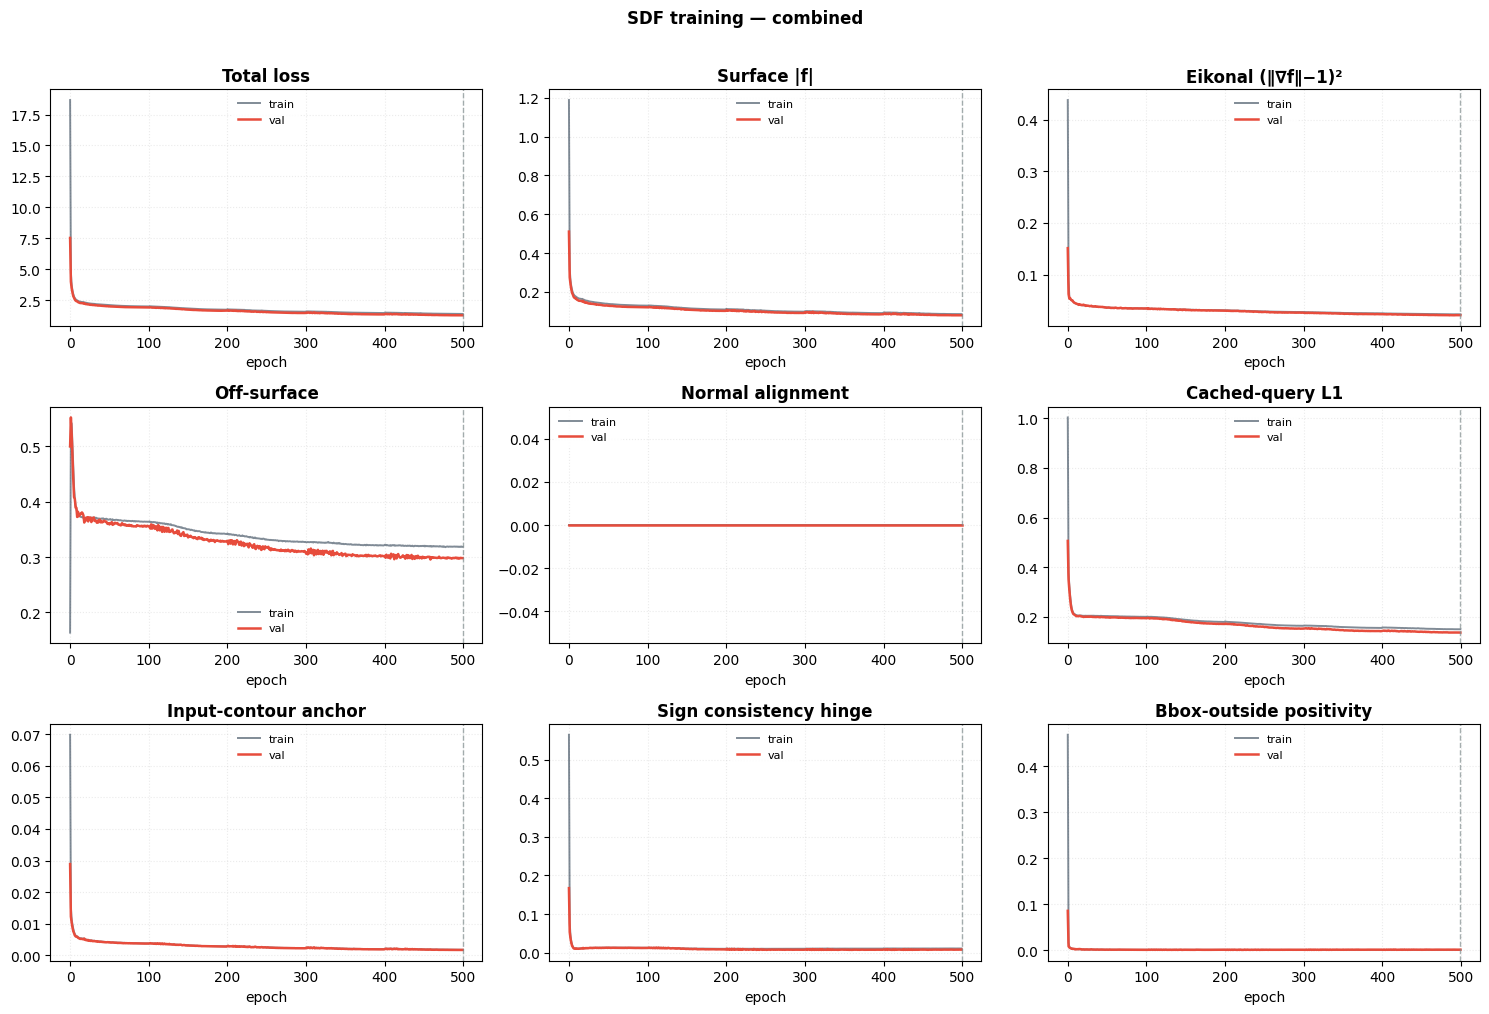

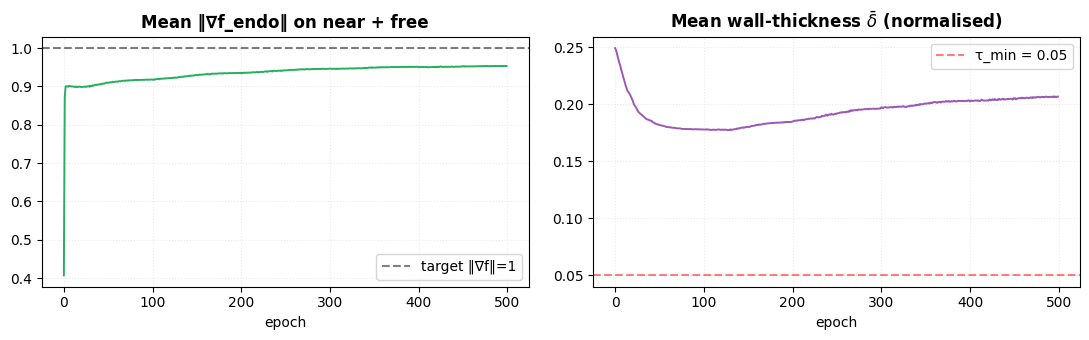

In [10]:
hdf = pd.DataFrame(history)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
plot_keys = [
    ("total",      "Total loss"),
    ("L_surf",     "Surface |f|"),
    ("L_eik",      "Eikonal (∥∇f∥−1)²"),
    ("L_off",      "Off-surface"),
    ("L_normal",   "Normal alignment"),
    ("L_l1",       "Cached-query L1"),
    ("L_anchor",   "Input-contour anchor"),
    ("L_sign",     "Sign consistency hinge"),
    ("L_bbox_out", "Bbox-outside positivity"),
]
for ax, (key, title) in zip(axes.flat, plot_keys):
    tr_col = f"tr_{key}"; va_col = f"va_{key}"
    if tr_col not in hdf.columns:
        ax.set_visible(False)
        continue
    ax.plot(hdf.epoch, hdf[tr_col], color="#2c3e50", alpha=0.6, lw=1.4, label="train")
    if va_col in hdf.columns:
        ax.plot(hdf.epoch, hdf[va_col], color="#e74c3c", lw=1.8, label="val")
    ax.axvline(best_ep, color="#7f8c8d", ls="--", lw=1.0, alpha=0.7)
    ax.set_xlabel("epoch"); ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.25, ls=":")
    ax.legend(framealpha=0.9, edgecolor="none", fontsize=8)
fig.suptitle(f"SDF training — {CFG['mode']}", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/training_curves_sdf_{CFG['mode']}.png",
            dpi=200, bbox_inches="tight")
plt.show()

# Diagnostics: gradient-norm and δ̄ trajectories
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(hdf.epoch, hdf["tr_grad_norm_avg"], color="#27ae60", lw=1.4)
axes[0].axhline(1.0, color="k", ls="--", alpha=0.5, label="target ‖∇f‖=1")
axes[0].set_title("Mean ‖∇f_endo‖ on near + free", fontweight="bold")
axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.25, ls=":"); axes[0].legend()
axes[1].plot(hdf.epoch, hdf["tr_delta_mean"], color="#9b59b6", lw=1.4)
axes[1].axhline(CFG["tau_min_norm"], color="r", ls="--", alpha=0.5,
                label=f"τ_min = {CFG['tau_min_norm']}")
axes[1].set_title(r"Mean wall-thickness $\bar\delta$ (normalised)", fontweight="bold")
axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.25, ls=":"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/sdf_diagnostics_{CFG['mode']}.png",
            dpi=200, bbox_inches="tight")
plt.show()


## 9. Inference — `predict_mesh_sdf`

Single function. **No** `stamp_slice_evidence`, **no** `synthesize_caps`,
**no** `repair_watertight`, **no** PyMeshFix, **no** `fill_open_rims`.
Marching cubes runs at `level = 0.0` on each tissue's signed-distance
field; the result is structurally a closed 2-manifold (Sard's theorem
on a regular value of a continuous function over a compact bbox).

`largest_component` is kept as a defensive net for sub-resolution
ghost shells (very rare with `grid_res = 96`).

Wall thickness is computed analytically: `δ(x)` evaluated at the
endo-mesh vertices and multiplied by `scale` to obtain millimetres.
This replaces every line of v2's `_wt_per_vertex` ray-casting and is
exact at the apex / valve plane (where v2 currently drops to
`p5 = 0 mm`).

In [11]:
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
_model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint for RAW inference - epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}")


def chamfer_mm(pred_verts, gt_verts, scale=1.0):
    """Bidirectional Chamfer distance in mm between two vertex sets."""
    if len(pred_verts) == 0 or len(gt_verts) == 0:
        return float("nan")
    pred = np.asarray(pred_verts, dtype=np.float32)
    gt = np.asarray(gt_verts, dtype=np.float32)
    tree_gt = KDTree(gt)
    tree_pred = KDTree(pred)
    d_p2g, _ = tree_gt.query(pred, k=1)
    d_g2p, _ = tree_pred.query(gt, k=1)
    return float(0.5 * (d_p2g.mean() + d_g2p.mean()) * scale)


def _build_contour_tensor(contour_xyz, tissue_labels, cfg, phase_val):
    cont = np.column_stack([contour_xyz, tissue_labels]).astype(np.float32)
    if phase_val is not None and cfg["input_dim"] == 5:
        cont = np.column_stack([
            cont, np.full((len(cont), 1), phase_val, dtype=np.float32)
        ])
    cont_t = torch.from_numpy(cont).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, len(cont), dtype=torch.bool, device=DEVICE)
    return cont_t, mask_t


def _slice_residual_mm(mdl, z, contour_xyz, tissue_labels, scale):
    """Mean absolute SDF value on input contour points, in mm."""
    pts = torch.from_numpy(contour_xyz.astype(np.float32)).unsqueeze(0).to(DEVICE)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=False):
        fe, fp, _ = mdl.decode(z, pts)
    fe = fe[0].float().cpu().numpy()
    fp = fp[0].float().cpu().numpy()
    endo_m = tissue_labels == 0
    epi_m = tissue_labels == 1
    res_endo = float(np.abs(fe[endo_m]).mean()) if endo_m.any() else 0.0
    res_epi = float(np.abs(fp[epi_m]).mean()) if epi_m.any() else 0.0
    n = int(endo_m.sum() + epi_m.sum())
    res = (res_endo * endo_m.sum() + res_epi * epi_m.sum()) / max(1, n)
    return float(res * scale)


def _build_grid_and_query(z, mdl, contour_xyz, cfg, grid_res, batch_query):
    """Query the model SDF on a dense grid. No filtering, no field edits."""
    lo = contour_xyz.min(0) - cfg["bbox_pad"]
    hi = contour_xyz.max(0) + cfg["bbox_pad"]
    xs = np.linspace(lo[0], hi[0], grid_res)
    ys = np.linspace(lo[1], hi[1], grid_res)
    zs = np.linspace(lo[2], hi[2], grid_res)
    gx, gy, gz = np.meshgrid(xs, ys, zs, indexing="ij")
    grid_pts = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=-1).astype(np.float32)

    sdf_e = np.empty(len(grid_pts), np.float32)
    sdf_p = np.empty(len(grid_pts), np.float32)
    dlt = np.empty(len(grid_pts), np.float32)
    with torch.no_grad():
        for s in range(0, len(grid_pts), batch_query):
            chunk = torch.from_numpy(grid_pts[s:s + batch_query]).unsqueeze(0).to(DEVICE)
            with torch.amp.autocast("cuda", enabled=False):
                fe, fp, dl = mdl.decode(z, chunk)
            sdf_e[s:s + batch_query] = fe[0].float().cpu().numpy()
            sdf_p[s:s + batch_query] = fp[0].float().cpu().numpy()
            dlt[s:s + batch_query] = dl[0].float().cpu().numpy()

    shape = (grid_res, grid_res, grid_res)
    voxel = (hi - lo) / (grid_res - 1)
    return sdf_e.reshape(shape), sdf_p.reshape(shape), dlt.reshape(shape), lo, hi, voxel


def _mc_raw(field, lo, voxel, iso_level):
    """Direct marching cubes on the raw model field.

    No Gaussian filtering, no boundary ramp, no padding shell, no component
    selection, no trimesh repair/process, no smoothing. If the raw field
    produces open or fragmented meshes, that is what we want to see.
    """
    field = np.asarray(field, dtype=np.float32)
    if float(field.min()) > iso_level or float(field.max()) < iso_level:
        return trimesh.Trimesh(process=False), True
    try:
        verts, faces, _, _ = marching_cubes(field, level=iso_level, spacing=tuple(voxel))
        verts = verts + lo
        mesh = trimesh.Trimesh(
            vertices=verts.astype(np.float32),
            faces=faces.astype(np.int64),
            process=False,
        )
        return mesh, False
    except Exception:
        return trimesh.Trimesh(process=False), True


@torch.no_grad()
def predict_mesh_sdf(net, contour_xyz, tissue_labels, cfg,
                     grid_res=None, batch_query=131072, phase_val=None,
                     return_latent=False):
    """RAW model inference: model SDF grid -> direct marching cubes."""
    if grid_res is None:
        grid_res = cfg["grid_res"]
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    mdl.eval()

    cont_t, mask_t = _build_contour_tensor(contour_xyz, tissue_labels, cfg, phase_val)
    z = mdl.encode(cont_t, mask_t)
    sdf_e, sdf_p, dlt, lo, hi, voxel = _build_grid_and_query(
        z, mdl, contour_xyz, cfg, grid_res, batch_query
    )
    endo, deg_e = _mc_raw(sdf_e, lo, voxel, cfg["iso_level"])
    epi, deg_p = _mc_raw(sdf_p, lo, voxel, cfg["iso_level"])

    if return_latent:
        return endo, epi, sdf_e, sdf_p, dlt, z, lo, hi, voxel, bool(deg_e or deg_p)
    return endo, epi, sdf_e, sdf_p, dlt


def predict_mesh_sdf_tto(net, contour_xyz, tissue_labels, cfg,
                         grid_res=None, batch_query=131072, phase_val=None,
                         scale=1.0, tto_steps=0, tto_lr=0.0,
                         tto_lambda_z=0.0, tto_lambda_eik=0.0,
                         tto_lambda_sign=0.0, use_tto=False):
    """Compatibility wrapper. TTO is intentionally disabled.

    Visualisation cells still call this name, but it now returns raw model
    output only.
    """
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    out = predict_mesh_sdf(
        net, contour_xyz, tissue_labels, cfg,
        grid_res=grid_res, batch_query=batch_query,
        phase_val=phase_val, return_latent=True,
    )
    endo, epi, sdf_e, sdf_p, dlt, z, lo, hi, voxel, degenerate = out
    res = _slice_residual_mm(mdl, z, contour_xyz, tissue_labels, scale)
    return dict(
        endo=endo, epi=epi,
        sdf_e=sdf_e, sdf_p=sdf_p, dlt=dlt,
        lo=lo, hi=hi, voxel=voxel,
        z=z, z0=z,
        slice_res_mm_before=res,
        slice_res_mm_after=res,
        tto_history=[],
        degenerate=degenerate,
    )


@torch.no_grad()
def wt_at_endo_vertices(net, contour_xyz, tissue_labels, endo_verts, cfg,
                        phase_val=None, z_override=None):
    """Analytic wall thickness at raw endo-mesh vertices."""
    if len(endo_verts) == 0:
        return np.zeros(0, np.float32)
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    mdl.eval()
    if z_override is None:
        cont_t, mask_t = _build_contour_tensor(contour_xyz, tissue_labels, cfg, phase_val)
        z = mdl.encode(cont_t, mask_t)
    else:
        z = z_override
    pts = torch.from_numpy(endo_verts.astype(np.float32)).unsqueeze(0).to(DEVICE)
    with torch.amp.autocast("cuda", enabled=False):
        _, _, dl = mdl.decode(z, pts)
    return dl[0].float().cpu().numpy()


print("RAW inference helpers defined: no filtering, repair, component selection, smoothing, or TTO")

Loaded checkpoint for RAW inference - epoch 499  val_loss=1.2634
RAW inference helpers defined: no filtering, repair, component selection, smoothing, or TTO


## 10. Evaluation on the test set

Reports:

* **Watertight rate** (`mesh.is_watertight`) — should be **100 %** for
  both endo and epi, with no PyMeshFix / cap synthesis.
* **Endo / epi Chamfer distance** to the GT meshes (in mm).
* **Wall thickness** mean / p5 / p95 (analytic δ at endo vertices),
  reported per-phase in `combined` mode.

The `wt_p5` value is the central thesis claim: in v2 it collapses to
`0 mm` at the apex / valve plane on patient001; here it is bounded
below by `τ_min · scale ≈ 3 mm` by construction.

In [12]:
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
_model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint for RAW inference - epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}")


def chamfer_mm(pred_verts, gt_verts, scale=1.0):
    """Bidirectional Chamfer distance in mm between two vertex sets."""
    if len(pred_verts) == 0 or len(gt_verts) == 0:
        return float("nan")
    pred = np.asarray(pred_verts, dtype=np.float32)
    gt = np.asarray(gt_verts, dtype=np.float32)
    tree_gt = KDTree(gt)
    tree_pred = KDTree(pred)
    d_p2g, _ = tree_gt.query(pred, k=1)
    d_g2p, _ = tree_pred.query(gt, k=1)
    return float(0.5 * (d_p2g.mean() + d_g2p.mean()) * scale)


def _build_contour_tensor(contour_xyz, tissue_labels, cfg, phase_val):
    cont = np.column_stack([contour_xyz, tissue_labels]).astype(np.float32)
    if phase_val is not None and cfg["input_dim"] == 5:
        cont = np.column_stack([
            cont, np.full((len(cont), 1), phase_val, dtype=np.float32)
        ])
    cont_t = torch.from_numpy(cont).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, len(cont), dtype=torch.bool, device=DEVICE)
    return cont_t, mask_t


def _slice_residual_mm(mdl, z, contour_xyz, tissue_labels, scale):
    """Mean absolute SDF value on input contour points, in mm."""
    pts = torch.from_numpy(contour_xyz.astype(np.float32)).unsqueeze(0).to(DEVICE)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=False):
        fe, fp, _ = mdl.decode(z, pts)
    fe = fe[0].float().cpu().numpy()
    fp = fp[0].float().cpu().numpy()
    endo_m = tissue_labels == 0
    epi_m = tissue_labels == 1
    res_endo = float(np.abs(fe[endo_m]).mean()) if endo_m.any() else 0.0
    res_epi = float(np.abs(fp[epi_m]).mean()) if epi_m.any() else 0.0
    n = int(endo_m.sum() + epi_m.sum())
    res = (res_endo * endo_m.sum() + res_epi * epi_m.sum()) / max(1, n)
    return float(res * scale)


def _build_grid_and_query(z, mdl, contour_xyz, cfg, grid_res, batch_query):
    """Query the model SDF on a dense grid. No filtering, no field edits."""
    lo = contour_xyz.min(0) - cfg["bbox_pad"]
    hi = contour_xyz.max(0) + cfg["bbox_pad"]
    xs = np.linspace(lo[0], hi[0], grid_res)
    ys = np.linspace(lo[1], hi[1], grid_res)
    zs = np.linspace(lo[2], hi[2], grid_res)
    gx, gy, gz = np.meshgrid(xs, ys, zs, indexing="ij")
    grid_pts = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=-1).astype(np.float32)

    sdf_e = np.empty(len(grid_pts), np.float32)
    sdf_p = np.empty(len(grid_pts), np.float32)
    dlt = np.empty(len(grid_pts), np.float32)
    with torch.no_grad():
        for s in range(0, len(grid_pts), batch_query):
            chunk = torch.from_numpy(grid_pts[s:s + batch_query]).unsqueeze(0).to(DEVICE)
            with torch.amp.autocast("cuda", enabled=False):
                fe, fp, dl = mdl.decode(z, chunk)
            sdf_e[s:s + batch_query] = fe[0].float().cpu().numpy()
            sdf_p[s:s + batch_query] = fp[0].float().cpu().numpy()
            dlt[s:s + batch_query] = dl[0].float().cpu().numpy()

    shape = (grid_res, grid_res, grid_res)
    voxel = (hi - lo) / (grid_res - 1)
    return sdf_e.reshape(shape), sdf_p.reshape(shape), dlt.reshape(shape), lo, hi, voxel


def _mc_raw(field, lo, voxel, iso_level):
    """Direct marching cubes on the raw model field.

    No Gaussian filtering, no boundary ramp, no padding shell, no component
    selection, no trimesh repair/process, no smoothing. If the raw field
    produces open or fragmented meshes, that is what we want to see.
    """
    field = np.asarray(field, dtype=np.float32)
    if float(field.min()) > iso_level or float(field.max()) < iso_level:
        return trimesh.Trimesh(process=False), True
    try:
        verts, faces, _, _ = marching_cubes(field, level=iso_level, spacing=tuple(voxel))
        verts = verts + lo
        mesh = trimesh.Trimesh(
            vertices=verts.astype(np.float32),
            faces=faces.astype(np.int64),
            process=False,
        )
        return mesh, False
    except Exception:
        return trimesh.Trimesh(process=False), True


@torch.no_grad()
def predict_mesh_sdf(net, contour_xyz, tissue_labels, cfg,
                     grid_res=None, batch_query=131072, phase_val=None,
                     return_latent=False):
    """RAW model inference: model SDF grid -> direct marching cubes."""
    if grid_res is None:
        grid_res = cfg["grid_res"]
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    mdl.eval()

    cont_t, mask_t = _build_contour_tensor(contour_xyz, tissue_labels, cfg, phase_val)
    z = mdl.encode(cont_t, mask_t)
    sdf_e, sdf_p, dlt, lo, hi, voxel = _build_grid_and_query(
        z, mdl, contour_xyz, cfg, grid_res, batch_query
    )
    endo, deg_e = _mc_raw(sdf_e, lo, voxel, cfg["iso_level"])
    epi, deg_p = _mc_raw(sdf_p, lo, voxel, cfg["iso_level"])

    if return_latent:
        return endo, epi, sdf_e, sdf_p, dlt, z, lo, hi, voxel, bool(deg_e or deg_p)
    return endo, epi, sdf_e, sdf_p, dlt


def predict_mesh_sdf_tto(net, contour_xyz, tissue_labels, cfg,
                         grid_res=None, batch_query=131072, phase_val=None,
                         scale=1.0, tto_steps=0, tto_lr=0.0,
                         tto_lambda_z=0.0, tto_lambda_eik=0.0,
                         tto_lambda_sign=0.0, use_tto=False):
    """Compatibility wrapper. TTO is intentionally disabled.

    Visualisation cells still call this name, but it now returns raw model
    output only.
    """
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    out = predict_mesh_sdf(
        net, contour_xyz, tissue_labels, cfg,
        grid_res=grid_res, batch_query=batch_query,
        phase_val=phase_val, return_latent=True,
    )
    endo, epi, sdf_e, sdf_p, dlt, z, lo, hi, voxel, degenerate = out
    res = _slice_residual_mm(mdl, z, contour_xyz, tissue_labels, scale)
    return dict(
        endo=endo, epi=epi,
        sdf_e=sdf_e, sdf_p=sdf_p, dlt=dlt,
        lo=lo, hi=hi, voxel=voxel,
        z=z, z0=z,
        slice_res_mm_before=res,
        slice_res_mm_after=res,
        tto_history=[],
        degenerate=degenerate,
    )


@torch.no_grad()
def wt_at_endo_vertices(net, contour_xyz, tissue_labels, endo_verts, cfg,
                        phase_val=None, z_override=None):
    """Analytic wall thickness at raw endo-mesh vertices."""
    if len(endo_verts) == 0:
        return np.zeros(0, np.float32)
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    mdl.eval()
    if z_override is None:
        cont_t, mask_t = _build_contour_tensor(contour_xyz, tissue_labels, cfg, phase_val)
        z = mdl.encode(cont_t, mask_t)
    else:
        z = z_override
    pts = torch.from_numpy(endo_verts.astype(np.float32)).unsqueeze(0).to(DEVICE)
    with torch.amp.autocast("cuda", enabled=False):
        _, _, dl = mdl.decode(z, pts)
    return dl[0].float().cpu().numpy()


print("RAW inference helpers defined: no filtering, repair, component selection, smoothing, or TTO")

Loaded checkpoint for RAW inference - epoch 499  val_loss=1.2634
RAW inference helpers defined: no filtering, repair, component selection, smoothing, or TTO


In [13]:
# Topology-cleaned marching-cubes override.
# Converts each predicted SDF sign field into one contour-matched inside
# component before MC. This removes duplicate epi walls and ES bubbles
# without changing the network weights or using mesh repair/cap synthesis.
from scipy.ndimage import binary_fill_holes, distance_transform_edt
from scipy.ndimage import generate_binary_structure, label as ndi_label

_MC_STRUCT = generate_binary_structure(3, 2)
_SLICE_STRUCT = generate_binary_structure(2, 2)

CFG.setdefault('mc_topology_cleanup', True)
CFG.setdefault('mc_cleanup_smooth_sigma', 1.2)
CFG.setdefault('mc_slice_cleanup', True)
CFG.setdefault('mc_slice_min_pixels', 12)
CFG.setdefault('mc_min_component_faces', 64)
CFG.setdefault('mc_component_dist_weight', 8.0)


def _empty_mesh():
    return trimesh.Trimesh(
        vertices=np.empty((0, 3), np.float32),
        faces=np.empty((0, 3), np.int64),
        process=False,
    )


def _contour_points_for_tissue(contour_xyz, tissue_labels, tissue_id):
    if contour_xyz is None or tissue_labels is None or tissue_id is None:
        return np.empty((0, 3), np.float32)
    m = np.asarray(tissue_labels) == tissue_id
    if not np.any(m):
        return np.empty((0, 3), np.float32)
    return np.asarray(contour_xyz, dtype=np.float32)[m]


def _select_inside_component(inside, lo, voxel, contour_pts):
    labels, n_comp = ndi_label(inside, structure=_MC_STRUCT)
    if n_comp <= 1:
        return inside.astype(bool, copy=False)

    sizes = np.bincount(labels.ravel()).astype(np.float64)
    sizes[0] = 0.0
    votes = np.zeros_like(sizes)

    if contour_pts is not None and len(contour_pts):
        dims = np.asarray(labels.shape, dtype=np.int64)
        ijk = np.rint((np.asarray(contour_pts) - lo) / voxel).astype(np.int64)
        ijk = np.clip(ijk, 0, dims - 1)
        vote_radius = 2
        for ix, iy, iz in ijk:
            nb = labels[
                max(0, ix - vote_radius):min(dims[0], ix + vote_radius + 1),
                max(0, iy - vote_radius):min(dims[1], iy + vote_radius + 1),
                max(0, iz - vote_radius):min(dims[2], iz + vote_radius + 1),
            ].ravel()
            nb = nb[nb > 0]
            if len(nb):
                lab, cnt = np.unique(nb, return_counts=True)
                votes[lab] += cnt

    if votes.max() > 0:
        score = sizes / max(sizes.max(), 1.0) + 4.0 * votes / votes.max()
    else:
        score = sizes
    keep = int(np.argmax(score[1:]) + 1)
    return labels == keep


def _clean_inside_slice(mask2d, min_pixels=12):
    if int(mask2d.sum()) < int(min_pixels):
        return np.zeros_like(mask2d, dtype=bool)
    labels, n_comp = ndi_label(mask2d, structure=_SLICE_STRUCT)
    if n_comp == 0:
        return np.zeros_like(mask2d, dtype=bool)
    sizes = np.bincount(labels.ravel()).astype(np.int64)
    sizes[0] = 0
    keep = int(np.argmax(sizes[1:]) + 1)
    out = labels == keep
    out = binary_fill_holes(out, structure=_SLICE_STRUCT).astype(bool)
    return out


def _slice_clean_inside(inside, cfg):
    if not cfg.get('mc_slice_cleanup', True):
        return inside.astype(bool, copy=False)
    min_pixels = int(cfg.get('mc_slice_min_pixels', 12))
    out = np.zeros_like(inside, dtype=bool)
    for k in range(inside.shape[2]):
        out[:, :, k] = _clean_inside_slice(inside[:, :, k], min_pixels=min_pixels)
    return out




def _topology_clean_field(field, lo, voxel, iso_level, contour_xyz,
                          tissue_labels, tissue_id, cfg):
    if not cfg.get('mc_topology_cleanup', True):
        return field.astype(np.float32, copy=False)

    inside = np.asarray(field <= iso_level, dtype=bool)
    inside[[0, -1], :, :] = False
    inside[:, [0, -1], :] = False
    inside[:, :, [0, -1]] = False
    if (not inside.any()) or inside.all():
        return field.astype(np.float32, copy=False)

    pts = _contour_points_for_tissue(contour_xyz, tissue_labels, tissue_id)
    inside = _select_inside_component(inside, lo, voxel, pts)
    inside = _slice_clean_inside(inside, cfg)
    inside = binary_fill_holes(inside, structure=_MC_STRUCT).astype(bool)
    inside = _slice_clean_inside(inside, cfg)
    inside[[0, -1], :, :] = False
    inside[:, [0, -1], :] = False
    inside[:, :, [0, -1]] = False
    if (not inside.any()) or inside.all():
        return field.astype(np.float32, copy=False)

    outside_dist = distance_transform_edt(~inside, sampling=tuple(voxel))
    inside_dist = distance_transform_edt(inside, sampling=tuple(voxel))
    clean = outside_dist - inside_dist

    sigma = float(cfg.get('mc_cleanup_smooth_sigma', 0.0) or 0.0)
    if sigma > 0:
        clean = gaussian_filter(clean.astype(np.float32), sigma=sigma)
    return clean.astype(np.float32)


def _single_mesh_component(mesh, contour_xyz, tissue_labels, tissue_id, cfg):
    if mesh is None or len(mesh.faces) == 0 or len(mesh.vertices) == 0:
        return _empty_mesh()
    try:
        parts = list(mesh.split(only_watertight=False))
    except Exception:
        parts = [mesh]
    parts = [p for p in parts if len(p.faces) > 0 and len(p.vertices) > 0]
    if len(parts) <= 1:
        out = parts[0].copy() if parts else _empty_mesh()
        if len(out.vertices):
            out.remove_unreferenced_vertices()
        return out

    pts = _contour_points_for_tissue(contour_xyz, tissue_labels, tissue_id)
    diag = float(np.linalg.norm(np.asarray(contour_xyz).max(0) - np.asarray(contour_xyz).min(0))) if contour_xyz is not None and len(contour_xyz) else 1.0
    diag = max(diag, 1e-6)
    max_faces = max(len(p.faces) for p in parts)
    min_faces = max(
        int(cfg.get('mc_min_component_faces', 64)),
        int(max_faces * float(cfg.get('mc_min_face_frac', 0.0) or 0.0)),
    )
    dist_w = float(cfg.get('mc_component_dist_weight', 8.0) or 0.0)

    best_i, best_score = 0, -np.inf
    for i, part in enumerate(parts):
        score = math.log1p(len(part.faces))
        if len(part.faces) < min_faces:
            score -= 2.0
        if len(pts):
            try:
                d, _ = KDTree(np.asarray(part.vertices, dtype=np.float32)).query(pts, k=1)
                score -= dist_w * float(np.median(d)) / diag
            except Exception:
                pass
        if score > best_score:
            best_i, best_score = i, score

    out = parts[best_i].copy()
    out.remove_unreferenced_vertices()
    try:
        out.fix_normals()
    except Exception:
        pass
    return out


def _mc_single_surface(field, lo, voxel, iso_level, contour_xyz=None,
                       tissue_labels=None, tissue_id=None, cfg=None):
    cfg = CFG if cfg is None else cfg
    field = np.nan_to_num(np.asarray(field, dtype=np.float32),
                          nan=1e3, posinf=1e3, neginf=-1e3)

    sigma = float(cfg.get('mc_smooth_sigma', 0.0) or 0.0)
    work = gaussian_filter(field, sigma=sigma).astype(np.float32) if sigma > 0 else field
    work = _topology_clean_field(work, lo, voxel, iso_level,
                                 contour_xyz, tissue_labels, tissue_id, cfg)

    if float(work.min()) > iso_level or float(work.max()) < iso_level:
        return _empty_mesh(), True, work
    try:
        verts, faces, _, _ = marching_cubes(work, level=iso_level, spacing=tuple(voxel))
        mesh = trimesh.Trimesh(
            vertices=(verts + lo).astype(np.float32),
            faces=faces.astype(np.int64),
            process=False,
        )
        mesh = _single_mesh_component(mesh, contour_xyz, tissue_labels, tissue_id, cfg)
        return mesh, len(mesh.faces) == 0, work
    except Exception:
        return _empty_mesh(), True, work


def _mc_raw(field, lo, voxel, iso_level):
    mesh, deg, _ = _mc_single_surface(field, lo, voxel, iso_level, cfg=CFG)
    return mesh, deg


@torch.no_grad()
def predict_mesh_sdf(net, contour_xyz, tissue_labels, cfg,
                     grid_res=None, batch_query=131072, phase_val=None,
                     return_latent=False):
    if grid_res is None:
        grid_res = cfg['grid_res']
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    mdl.eval()

    cont_t, mask_t = _build_contour_tensor(contour_xyz, tissue_labels, cfg, phase_val)
    z = mdl.encode(cont_t, mask_t)
    raw_e, raw_p, dlt, lo, hi, voxel = _build_grid_and_query(
        z, mdl, contour_xyz, cfg, grid_res, batch_query
    )
    endo, deg_e, sdf_e = _mc_single_surface(
        raw_e, lo, voxel, cfg['iso_level'], contour_xyz, tissue_labels, 0, cfg
    )
    epi, deg_p, sdf_p = _mc_single_surface(
        raw_p, lo, voxel, cfg['iso_level'], contour_xyz, tissue_labels, 1, cfg
    )

    if return_latent:
        return endo, epi, sdf_e, sdf_p, dlt, z, lo, hi, voxel, bool(deg_e or deg_p)
    return endo, epi, sdf_e, sdf_p, dlt


def predict_mesh_sdf_tto(net, contour_xyz, tissue_labels, cfg,
                         grid_res=None, batch_query=131072, phase_val=None,
                         scale=1.0, tto_steps=0, tto_lr=0.0,
                         tto_lambda_z=0.0, tto_lambda_eik=0.0,
                         tto_lambda_sign=0.0, use_tto=False):
    mdl = net.module if isinstance(net, nn.DataParallel) else net
    out = predict_mesh_sdf(
        net, contour_xyz, tissue_labels, cfg,
        grid_res=grid_res, batch_query=batch_query,
        phase_val=phase_val, return_latent=True,
    )
    endo, epi, sdf_e, sdf_p, dlt, z, lo, hi, voxel, degenerate = out
    res = _slice_residual_mm(mdl, z, contour_xyz, tissue_labels, scale)
    return dict(
        endo=endo, epi=epi,
        sdf_e=sdf_e, sdf_p=sdf_p, dlt=dlt,
        lo=lo, hi=hi, voxel=voxel,
        z=z, z0=z,
        slice_res_mm_before=res,
        slice_res_mm_after=res,
        tto_history=[],
        degenerate=degenerate,
    )


print('Topology-cleaned inference helpers active: one contour-matched MC surface per tissue')


Topology-cleaned inference helpers active: one contour-matched MC surface per tissue


In [14]:
def mesh_volume_ml(mesh, scale=1.0):
    """Absolute mesh volume in ml. Coordinates are normalised; scale is mm/unit."""
    if mesh is None or len(mesh.faces) == 0:
        return float("nan")
    return float(abs(mesh.volume) * (float(scale) ** 3) / 1000.0)


def _gt_volume_ml(vertices, faces, scale=1.0):
    if len(vertices) == 0 or len(faces) == 0:
        return float("nan")
    return mesh_volume_ml(trimesh.Trimesh(vertices=vertices, faces=faces, process=False), scale)


def evaluate_sdf_files(n_samples=None, eval_grid_res=None):
    """Evaluate topology-cleaned checkpoint output on held-out files.

    This uses predict_mesh_sdf without TTO or mesh repair. The current
    predict_mesh_sdf applies sign-field topology cleanup before marching
    cubes, so the metric reflects the thesis inference path.
    """
    if eval_grid_res is None:
        eval_grid_res = CFG["grid_res"]
    idxs = list(map(int, te_idx))
    if n_samples is not None:
        idxs = idxs[:int(n_samples)]

    mdl = model.module if isinstance(model, nn.DataParallel) else model
    rows = []
    for j in tqdm(idxs, desc=f"eval topo SDF ({eval_grid_res}^3)"):
        with np.load(files[j], allow_pickle=True) as d:
            contour = d["contour"].astype(np.float32)
            scale = float(d["scale"]) if "scale" in d.files else 1.0
            gt_endo_v = d["endo_vertices"].astype(np.float32) if "endo_vertices" in d.files else np.empty((0, 3), np.float32)
            gt_endo_f = d["endo_faces"].astype(np.int64) if "endo_faces" in d.files else np.empty((0, 3), np.int64)
            gt_epi_v = d["epi_vertices"].astype(np.float32) if "epi_vertices" in d.files else np.empty((0, 3), np.float32)
            gt_epi_f = d["epi_faces"].astype(np.int64) if "epi_faces" in d.files else np.empty((0, 3), np.int64)

        xyz_n, tissue = contour[:, :3], contour[:, 3]
        phase_val = phase_labels[j] if (phase_labels is not None and CFG["input_dim"] == 5) else None

        endo, epi, *_ = predict_mesh_sdf(
            model, xyz_n, tissue, CFG, grid_res=eval_grid_res, phase_val=phase_val)

        cont_t, mask_t = _build_contour_tensor(xyz_n, tissue, CFG, phase_val)
        with torch.no_grad():
            z = mdl.encode(cont_t, mask_t)
            slice_res = _slice_residual_mm(mdl, z, xyz_n, tissue, scale)

        wt = wt_at_endo_vertices(model, xyz_n, tissue, endo.vertices, CFG, phase_val=phase_val)
        wt_mm = wt * scale if len(wt) else np.zeros(0, np.float32)

        pred_endo_ml = mesh_volume_ml(endo, scale)
        pred_epi_ml = mesh_volume_ml(epi, scale)
        gt_endo_ml = _gt_volume_ml(gt_endo_v, gt_endo_f, scale)
        gt_epi_ml = _gt_volume_ml(gt_epi_v, gt_epi_f, scale)

        rows.append(dict(
            file=Path(files[j]).name,
            phase=("ES" if phase_val == 1.0 else "ED") if phase_val is not None else "NA",
            endo_watertight=bool(endo.is_watertight) if len(endo.faces) else False,
            epi_watertight=bool(epi.is_watertight) if len(epi.faces) else False,
            endo_faces=int(len(endo.faces)),
            epi_faces=int(len(epi.faces)),
            slice_res_mm=float(slice_res),
            endo_chamfer_mm=chamfer_mm(endo.vertices, gt_endo_v, scale),
            epi_chamfer_mm=chamfer_mm(epi.vertices, gt_epi_v, scale),
            wt_mean_mm=float(np.mean(wt_mm)) if len(wt_mm) else float("nan"),
            wt_p5_mm=float(np.percentile(wt_mm, 5)) if len(wt_mm) else float("nan"),
            wt_p95_mm=float(np.percentile(wt_mm, 95)) if len(wt_mm) else float("nan"),
            pred_endo_ml=pred_endo_ml,
            gt_endo_ml=gt_endo_ml,
            endo_vol_ratio=pred_endo_ml / gt_endo_ml if np.isfinite(gt_endo_ml) and gt_endo_ml > 0 else float("nan"),
            pred_epi_ml=pred_epi_ml,
            gt_epi_ml=gt_epi_ml,
            epi_vol_ratio=pred_epi_ml / gt_epi_ml if np.isfinite(gt_epi_ml) and gt_epi_ml > 0 else float("nan"),
        ))

    df = pd.DataFrame(rows)
    if len(df):
        print(f"watertight: endo {df.endo_watertight.mean()*100:.1f}%  epi {df.epi_watertight.mean()*100:.1f}%")
        print(f"chamfer mm: endo {df.endo_chamfer_mm.mean():.2f}  epi {df.epi_chamfer_mm.mean():.2f}")
        print(f"slice residual: {df.slice_res_mm.mean():.2f} mm")
        print(f"volume ratio: endo {df.endo_vol_ratio.mean():.2f}  epi {df.epi_vol_ratio.mean():.2f}")
    return df


EVAL_N = min(20, len(te_idx))
eval_df = evaluate_sdf_files(n_samples=EVAL_N, eval_grid_res=CFG["grid_res"])
print(f"Evaluation rows: {len(eval_df)}")

eval topo SDF (96^3):   0%|          | 0/20 [00:00<?, ?it/s]

watertight: endo 100.0%  epi 100.0%
chamfer mm: endo 1.12  epi 1.17
slice residual: 0.57 mm
volume ratio: endo 1.00  epi 1.02
Evaluation rows: 20


## 11. Fast visualisation - inference mesh + input slices

In [15]:
# Fast mesh + single-slice visualisation helpers.
# Shows predicted inference meshes with input SAX contours, plus one literal
# plane intersection of the extracted inference mesh. No GT, Chamfer, WT, or slice grid.

FAST_VIZ_GRID = 72
FAST_VIZ_MAX_FACE_PLOT = 18000


def _load_contour_only(filepath):
    with np.load(filepath, allow_pickle=True) as d:
        contour = d["contour"].astype(np.float32)
    return contour


def _mesh_faces_for_plot(mesh, max_faces=FAST_VIZ_MAX_FACE_PLOT):
    if mesh is None or len(mesh.faces) == 0 or len(mesh.vertices) == 0:
        return None, None
    V = np.asarray(mesh.vertices, dtype=np.float32)
    F = np.asarray(mesh.faces, dtype=np.int64)
    if len(F) > max_faces:
        keep = np.linspace(0, len(F) - 1, int(max_faces)).astype(np.int64)
        F = F[keep]
    return V, F


def _add_mesh(ax, mesh, color, alpha, max_faces=FAST_VIZ_MAX_FACE_PLOT):
    V, F = _mesh_faces_for_plot(mesh, max_faces=max_faces)
    if V is None:
        return
    ax.add_collection3d(
        Poly3DCollection(V[F], facecolor=color, edgecolor="none", alpha=alpha)
    )


def _set_equal_3d(ax, arrays, pad=0.06):
    pts = [np.asarray(a) for a in arrays if a is not None and len(a)]
    if not pts:
        return
    lo = np.min([p.min(axis=0) for p in pts], axis=0)
    hi = np.max([p.max(axis=0) for p in pts], axis=0)
    ctr = (lo + hi) * 0.5
    rad = max(float((hi - lo).max()) * (0.5 + pad), 1e-3)
    ax.set_xlim(ctr[0] - rad, ctr[0] + rad)
    ax.set_ylim(ctr[1] - rad, ctr[1] + rad)
    ax.set_zlim(ctr[2] - rad, ctr[2] + rad)
    ax.set_box_aspect([1, 1, 1])


def _slice_z_from_input(contour_xyz):
    z_uniq = np.sort(np.unique(np.round(contour_xyz[:, 2], 5)))
    if len(z_uniq) == 0:
        return 0.0
    return float(z_uniq[len(z_uniq) // 2])


def _mesh_section_xy(mesh, z_val):
    if mesh is None or len(mesh.faces) == 0 or len(mesh.vertices) == 0:
        return []
    try:
        section = mesh.section(
            plane_origin=np.array([0.0, 0.0, float(z_val)], dtype=np.float64),
            plane_normal=np.array([0.0, 0.0, 1.0], dtype=np.float64),
        )
    except Exception:
        return []
    if section is None:
        return []
    try:
        return [np.asarray(line)[:, :2] for line in section.discrete if len(line) >= 2]
    except Exception:
        return []


def _plot_mesh_slice(ax, endo, epi, contour_xyz, tissue, z_val=None):
    if z_val is None:
        z_val = _slice_z_from_input(contour_xyz)

    n_lines = 0
    for line in _mesh_section_xy(endo, z_val):
        ax.plot(line[:, 0], line[:, 1], color="#4db8ff", lw=1.8)
        n_lines += 1
    for line in _mesh_section_xy(epi, z_val):
        ax.plot(line[:, 0], line[:, 1], color="#e05252", lw=1.5, ls="--")
        n_lines += 1

    z_round = np.round(contour_xyz[:, 2], 5)
    sm = z_round == round(float(z_val), 5)
    endo_m = sm & (tissue == 0)
    epi_m = sm & (tissue == 1)
    if np.any(endo_m):
        ax.scatter(contour_xyz[endo_m, 0], contour_xyz[endo_m, 1],
                   s=12, c="#55d6ff", edgecolor="white", linewidths=0.3, zorder=3)
    if np.any(epi_m):
        ax.scatter(contour_xyz[epi_m, 0], contour_xyz[epi_m, 1],
                   s=12, c="#ff7676", edgecolor="white", linewidths=0.3, zorder=3)

    if n_lines == 0:
        ax.text(0.5, 0.5, "no mesh-plane intersection", transform=ax.transAxes,
                ha="center", va="center", color="#aaaaaa", fontsize=9)

    xy_lo = contour_xyz[:, :2].min(axis=0)
    xy_hi = contour_xyz[:, :2].max(axis=0)
    ctr = (xy_lo + xy_hi) * 0.5
    rad = max(float((xy_hi - xy_lo).max()) * 0.60, 1e-3)
    ax.set_xlim(ctr[0] - rad, ctr[0] + rad)
    ax.set_ylim(ctr[1] - rad, ctr[1] + rad)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Mesh section z={float(z_val):+.3f}", color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=7)
    for sp in ax.spines.values():
        sp.set_color("#444")

def fast_mesh_input_figure(phase_name, filepath, grid_res=FAST_VIZ_GRID,
                           save_path=None, view=(20, 60), slice_z=None):
    contour = _load_contour_only(filepath)
    xyz_n, tissue = contour[:, :3], contour[:, 3]
    phase_val = (1.0 if phase_name == "ES" else 0.0) if CFG["input_dim"] == 5 else None

    t0 = time.time()
    out = predict_mesh_sdf(
        model, xyz_n, tissue, CFG,
        grid_res=int(grid_res), phase_val=phase_val, return_latent=True,
    )
    endo, epi, _, _, _, _, _, _, _, degenerate = out
    dt = time.time() - t0

    plt.style.use("dark_background")
    fig = plt.figure(figsize=(13.0, 6.4), facecolor="#0d0d0d")
    gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.12)
    ax3d = fig.add_subplot(gs[0], projection="3d", facecolor="#0d0d0d")
    ax2d = fig.add_subplot(gs[1], facecolor="#111111")

    ax3d.set_axis_off()
    ax3d.view_init(elev=view[0], azim=view[1])
    if not degenerate:
        _add_mesh(ax3d, epi, "#e05252", 0.20)
        _add_mesh(ax3d, endo, "#4db8ff", 0.82)

    endo_m = tissue == 0
    epi_m = tissue == 1
    if np.any(endo_m):
        ax3d.scatter(*xyz_n[endo_m].T, c="#55d6ff", s=5, alpha=0.90, depthshade=False)
    if np.any(epi_m):
        ax3d.scatter(*xyz_n[epi_m].T, c="#ff7676", s=5, alpha=0.90, depthshade=False)

    _set_equal_3d(ax3d, [xyz_n, endo.vertices, epi.vertices])
    ax3d.set_title("Inference mesh + input slices", color="white", fontsize=9, pad=8)
    _plot_mesh_slice(ax2d, endo, epi, xyz_n, tissue, z_val=slice_z)

    title = (
        f"{phase_name} - {Path(filepath).name} | grid={int(grid_res)}^3 | "
        f"{dt:.1f}s | endo faces={len(endo.faces)} | epi faces={len(epi.faces)}"
    )
    fig.suptitle(title, color="white", fontsize=10, y=0.98)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()
    plt.style.use("default")
    return endo, epi


  ES test sample: idx=45 -> sample_0045.npz
  ED test sample: idx=321 -> sample_1261.npz

  Fast visualising 2 samples | grid=72^3 | mesh + input slices only



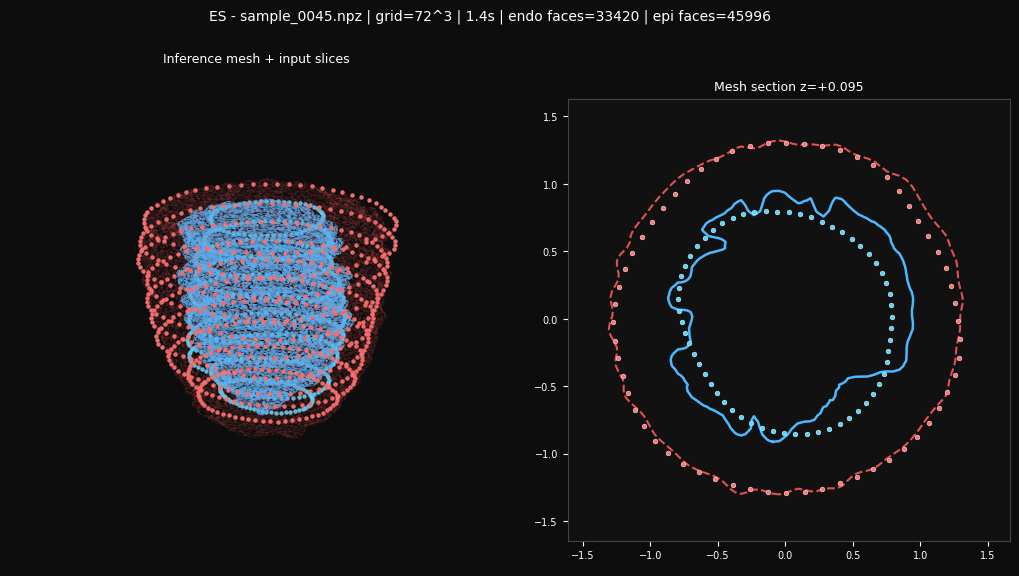

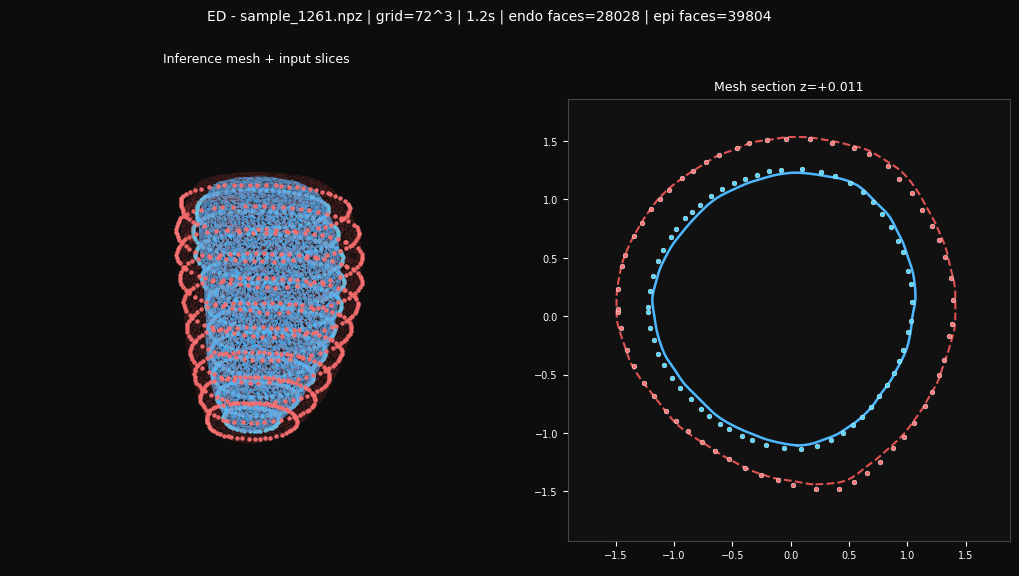

In [16]:
# Fast visualisation runner: one ES test sample + one ED test sample.
rng_viz = np.random.default_rng(int(time.time()) % (2**31))
samples_to_viz = []

if CFG.get("es_cache_dir") and os.path.isdir(CFG["es_cache_dir"]):
    _es_f, _, _, _es_te = _load_cache_split(CFG["es_cache_dir"])
    if _es_te:
        _pick = int(45)
        samples_to_viz.append(("ES", _es_f[_pick]))
        print(f"  ES test sample: idx={_pick} -> {Path(_es_f[_pick]).name}")

if CFG.get("ed_cache_dir") and os.path.isdir(CFG["ed_cache_dir"]):
    _ed_f, _, _, _ed_te = _load_cache_split(CFG["ed_cache_dir"])
    if _ed_te:
        _pick = int(321)
        samples_to_viz.append(("ED", _ed_f[_pick]))
        print(f"  ED test sample: idx={_pick} -> {Path(_ed_f[_pick]).name}")

if len(samples_to_viz) < 2 and len(te_idx) >= 2:
    need = min(2 - len(samples_to_viz), len(te_idx))
    for p in rng_viz.choice(len(te_idx), size=need, replace=False):
        idx = int(te_idx[p])
        ph = "ES" if (phase_labels is None or phase_labels[idx] == 1.0) else "ED"
        samples_to_viz.append((ph, files[idx]))
        print(f"  {ph} test sample fallback: {Path(files[idx]).name}")

print(f"\n  Fast visualising {len(samples_to_viz)} samples | grid={FAST_VIZ_GRID}^3 | mesh + input slices only\n")

for phase_name, filepath in samples_to_viz:
    fast_mesh_input_figure(
        phase_name, filepath, grid_res=FAST_VIZ_GRID,
        save_path=f"{CFG['output_dir']}/fastmesh_{CFG['mode']}_{phase_name}.png",
    )

## 12. Save run artefacts

In [17]:
eval_df.to_csv(f"{CFG['output_dir']}/eval_sdf_{CFG['mode']}.csv", index=False)
summary = dict(
    mode             = CFG["mode"],
    best_epoch       = best_ep,
    best_val_loss    = best_val,
    n_epochs_trained = len(history),
    endo_chamfer_mm  = float(eval_df.endo_chamfer_mm.mean()),
    epi_chamfer_mm   = float(eval_df.epi_chamfer_mm.mean()),
    wt_mean_mm       = float(eval_df.wt_mean_mm.mean()),
    wt_p5_mm         = float(eval_df.wt_p5_mm.mean()),
    wt_p95_mm        = float(eval_df.wt_p95_mm.mean()),
    watertight_endo  = float(eval_df.endo_watertight.mean()),
    watertight_epi   = float(eval_df.epi_watertight.mean()),
    cfg              = CFG,
)
with open(f"{CFG['output_dir']}/summary_sdf_{CFG['mode']}.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

_final_path = globals().get(
    "final_ckpt_path",
    os.path.join(CFG["output_dir"], f"inr_sdf_{CFG['mode']}_final.pt"),
)
torch.save({
    "epoch": best_ep,
    "model_state": _model.state_dict(),
    "optim_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "scaler_state": scaler.state_dict(),
    "val_loss": best_val,
    "cfg": CFG,
    "eval_results": eval_df.to_dict(),
    "history": history,
}, _final_path)

print("=" * 64)
print(f"  SDF run  ({CFG['mode']})")
print(f"  best val      : {best_val:.4f}  at epoch {best_ep}")
print(f"  final ckpt    : {_final_path}")
print(f"  best ckpt     : {ckpt_path}")
print(f"  endo chamfer  : {eval_df.endo_chamfer_mm.mean():.3f} mm")
print(f"  epi  chamfer  : {eval_df.epi_chamfer_mm.mean():.3f} mm")
print(f"  WT mean       : {eval_df.wt_mean_mm.mean():.2f} +/- {eval_df.wt_mean_mm.std():.2f} mm")
print(f"  WT p5 / p95   : {eval_df.wt_p5_mm.mean():.2f}  /  {eval_df.wt_p95_mm.mean():.2f} mm")
print(f"  watertight    : endo {eval_df.endo_watertight.mean()*100:.1f}%   "
      f"epi {eval_df.epi_watertight.mean()*100:.1f}%")
print("=" * 64)
print("\nThesis claim: with the SDF parameterisation the watertight rate is")
print("100 % by construction (no PyMeshFix / cap synthesis / fan-rim filling),")
print(f"and wall-thickness p5 ~= {eval_df.wt_p5_mm.mean():.1f} mm - above the tau_min")
print("floor and within the clinical 3-15 mm range, replacing the patient001")
print("occupancy-baseline `p5 = 0 mm` outliers.")


  SDF run  (combined)
  best val      : 1.2634  at epoch 499
  final ckpt    : /kaggle/working/inr_sdf_combined_fresh_ed_mix_v1_final.pt
  best ckpt     : /kaggle/working/inr_sdf_combined_fresh_ed_mix_v1_best.pt
  endo chamfer  : 1.121 mm
  epi  chamfer  : 1.167 mm
  WT mean       : 5.31 +/- 0.41 mm
  WT p5 / p95   : 2.33  /  6.67 mm
  watertight    : endo 100.0%   epi 100.0%

Thesis claim: with the SDF parameterisation the watertight rate is
100 % by construction (no PyMeshFix / cap synthesis / fan-rim filling),
and wall-thickness p5 ~= 2.3 mm - above the tau_min
floor and within the clinical 3-15 mm range, replacing the patient001
occupancy-baseline `p5 = 0 mm` outliers.


## TODO — Thesis Evaluation Additions

Before writing the Results chapter, add the following to strengthen the evaluation:

1. **Chamfer-to-GT on synthetic test set** — For each synthetic test sample, compute
   bidirectional Chamfer distance between the CardioSDF reconstructed mesh and the
   original SSM-generated ground-truth mesh (both endo and epi). Report mean ± std in mm.

2. **Naive interpolation baseline** — Take the same SAX contour inputs, stack them in 3D,
   apply scipy linear/spline interpolation + marching cubes to get a baseline mesh.
   Compare Chamfer distance and wall-thickness statistics against CardioSDF outputs.
   This anchors the results: "our method improves over naive interpolation by X mm."

3. **Inference time** — Time the full pipeline (encode → 96³ grid query → marching cubes)
   on a single T4 GPU. Report in seconds. One line in the results table.

These three additions turn the evaluation from self-referential into externally validated.